# UNDERSTANDING FACTORS AFFECTING BIKE USAGE

- Yulu is India's leading micro-mobility service provider, which offers unique vehicles for the daily commute. Starting off as a mission to eliminate traffic congestion in India, Yulu provides the safest commute solution through a user-friendly mobile app to enable shared, solo and sustainable commuting.
    
- Yulu zones are located at all the appropriate locations (including metro stations, bus stands, office spaces, residential areas, corporate offices, etc) to make those first and last miles smooth, affordable, and convenient.
    
- Yulu has recently suffered considerable dips in its revenues. They have contracted a consulting company to understand the factors on which the demand for these shared electric cycle depends. Specifically, they want to understand the factors affecting the demand for these shared electric cycles in the Indian market

## TABLE OF CONTENTS

- [1. Objective](#1-objective)
- [2. Data Description](#2-data-description)
  - [2.1 Data Wrangling / Cleaning / Tidying](#21-data-wrangling-cleaning-tidying)
- [3. Exploratory Data Analysis (EDA)](#3-exploratory-data-analysis-eda)
  - [3.1 Outlier Detection](#31-outlier-detection)
  - [3.2 Univariate Analysis](#32-univariate-analysis)
  - [3.3 Bivariate Analysis](#33-bivariate-analysis)
    - [3.3.1 Relations Between Continuous Variables and Total Users](#331-relations-between-continuous-variables-and-total-users)
    - [3.3.2 Relations Between Categorical Variables and Total Users](#332-relations-between-categorical-variable-and-total-users)
    - [3.3.3 Relations Between Datetime and Total Users](#333-relations-between-datetime-and-total-users)
- [4. Statistical Analysis](#4-statistical-analysis)
  - [4.1 Categorical Variables](#41-categorical-variables)
    - [4.1.1 Two Sample T-Tests](#411-two-sample-t-tests)
    - [4.1.2 Welch's ANOVA and Games-Howell Post-hoc Test](#412-welchs-anova-and-games-howell-post-hoc-test)
  - [4.2 Continuous Variables](#42-continuous-variables)
    - [4.2.1 Pearson Correlation](#421-pearson-correlation)
- [5. Modeling](#5-modeling)
  - [5.1 Baseline Regression](#51-baseline-regression)
  - [5.2 Stage 1 Diagnostics & Model Refinement](#52-stage-1-diagnostic-model-refinement)
  - [5.3 Stage 2 Diagnostics & Model Refinement](#53-stage-2-diagnostic-model-refinement)
  - [5.4 Stage 3 Diagnostics & Model Refinement](#54-stage-3-diagnostic-&-model-refinement)
- [6. Communication and Reporting](#6-communication-and-reporting)

<div style="background-color: #e6f7ff; padding: 10px;">
<b>EXECUTIVE SUMMARY</b><br>
<ul>
    <li><b>Key findings</b>: Bike rentals were positively affected by hour of the day (peaks in the afternoon around 3pm, lowest in the early morning around 3am), June-August has highest bike rentals compared to baseline January, and on Saturday when compared to baseline Monday. Misty weather negatively affects bike rentals. Temperature has weak positive effect, while light precipitation weather and windspeed have weak negative effects on bike rentals. </li>
    <li><b>Diagnostics</b>: The baseline model showed heteroscedasticity and non-normal residuals. Log transformation improved normality but heteroscedasticity persists, confirmed by Breusch-Pagan and White tests.</li>
    <li><b>Corrective action</b>: Robust standard errors (HC3) were applied to the logged model. Coefficient estimates remain unchanged, but inference is now valid.</li>
    <li><b>Conclusion</b>: The final model reliably identifies temporal (hour, day, month), seasonal, weather and environmental effect on bike rentals. Although heteroscedasticity was detected, inference was corrected using robust HC3 standard errors, ensuring that results are statistically valid and trustworthy for stakeholder interpretation.</li>
</ul>
</div>

## 1. OBJECTIVE 

- The objective of this analysis is to find out which variables are significant in predicting the demand for shared electric cycles in the Indian market.

## 2. DATA DESCRIPTION

- The datasheet was obtained from Kaggle.com.

<div style="background-color:#fff8e1; padding:10px;">
<table style="background-color: #f0fff0; border-collapse:collapse;">
    <tr><th>Feature</th><th>Description</th></tr>
    <tr><td>datetime</td><td>Date and Time</td></tr>
    <tr><td>season</td>
        <td>
            <ul>
                <li>1: spring</li>
                <li>2: summer</li>
                <li>3: fall</li>
                <li>4: winter</li>
        </td>
    </tr>
    <tr><td>holiday</td>
        <td>
            <ul>
                <li>0: no</li>
                <li>1: yes</li>
            </ul>
        </td>
    </tr>
    <tr><td>workingday</td>
        <td>
            <ul>
                <li>0: no (weekend or holiday)</li>
                <li>1: yes</li>
            </ul>
        </td>
    </tr>
    <tr><td>weather</td>
        <td>
            <ul>
                <li>1: Clear, few clouds, partly cloudy (clear)</li>
                <li>2: Mist + cloudy, mist + broken clouds, mist + few clouds, mist (misty)</li>
                <li>3: Light snow, light rain + thunderstorm + scattered clouds, light rain + scattered clouds (light precipitation)</li>
                <li>4: Heavy rain + ice pallets + thunderstorm + mist, snow + fog (heavy precipitation)</li>
            </ul>
        </td>
    </tr>
    <tr><td>temp</td><td>temperature in Celcius</td></tr>
    <tr><td>atemp</td><td>apparent temperature in Celcius</td></tr>
    <tr><td>humidity</td><td>humidity</td></tr>
    <tr><td>windspeed</td><td>wind speed</td></tr>
    <tr><td>casual</td><td>count of casual users</td></tr>
    <tr><td>registered</td><td>count of registered users</td></tr>
    <tr><td>count</td><td>count of total users</td></tr>
</table>
</div>

### 2.1 Data Wrangling / Cleaning / Tidying

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pingouin as pg

## Had problem with statsmodels.api before
## Had to uninstall scipy and delete ~ipy, ~ipy.libs, scipy, scipy.libs manually
# %pip uninstall scipy -y

## reinstalling scipy
# pip install scipy

## Upgrading scipy and statsmodels to its latest patch. It had problem with lazywhere before
# pip install --upgrade statsmodels scipy

# Import the latest scipy and statsmodels, and check its' version
import scipy, statsmodels
#print(scipy.__version__, statsmodels.__version__)

from scipy.stats import binned_statistic
import statsmodels.api as sm

from scipy.stats import ttest_ind, levene
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import het_white

In [69]:
# Load dataframe
df = pd.read_csv('yulu_bike_sharing_dataset.csv')

# Inspect first five rows
print(df.head())

              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  


<div style="background-color: #e6f7ff; padding: 10px;">
    <ul>
        <li>Since column 'count' could be confusing in analysis later, the column has been renamed as 'total_users' instead.</li>
    </ul>
</div>

In [70]:
# Renaming column 'count' as 'total_users'
df.rename(columns={'count': 'total_users'}, inplace=True)

<div style="background-color: #e6f7ff; padding: 10px;">
    <ul> 
        <li>The dataset provided seems has no missing values, but the datatype need to be reassigned.</li>
        <li>For example; 'season', 'holiday', 'workingday', and 'weather' can be changed into categorical datatype. 'datetime' could also be converted into datetime data type.</li>
    </ul>
</div>

In [71]:
# Checking non-null count and datatype
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   datetime     10886 non-null  str    
 1   season       10886 non-null  int64  
 2   holiday      10886 non-null  int64  
 3   workingday   10886 non-null  int64  
 4   weather      10886 non-null  int64  
 5   temp         10886 non-null  float64
 6   atemp        10886 non-null  float64
 7   humidity     10886 non-null  int64  
 8   windspeed    10886 non-null  float64
 9   casual       10886 non-null  int64  
 10  registered   10886 non-null  int64  
 11  total_users  10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1.2 MB


In [72]:
# Reassign correct data type accordingly
df['datetime'] = pd.to_datetime(df['datetime'])

# Assign all categorical columns into a list, and assign each as 'category' datatype
cat_cols = ['season', 'holiday', 'workingday', 'weather']
for i in cat_cols:
    df[i] = df[i].astype('category')

<div style="background-color: #e6f7ff; padding: 10px;">
    <ul>
        <li>There are no duplicates in this dataframe.</li>
    </ul>
</div>

In [73]:
# Check the sum of duplicated rows
df.duplicated().sum()

np.int64(0)

<div style="background-color: #e6f7ff; padding: 10px;">
    <ul>
        <li>The column 'datetime' can be further split into 'year', 'month', 'day', and 'hour'. This way I can investigate further usages at specific point.</li>
    </ul>
</div>

In [74]:
# Spliting column 'datetime' further into 'year', 'month', 'day', and 'hour'
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day_of_week'] = df['datetime'].dt.dayofweek
df['hour'] = df['datetime'].dt.hour

df['day_of_week'] = df['day_of_week'].map({
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun'
})
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>In order for the model to understands 'month' and 'hour' circular nature (December is close to January, not December is greater than January, and 23 is close to 0, not 23 greater than 0), cylical encoding has to be done.</li>
    <li>This is preserve cyclical structure and this approach avoids artificial breaks at midnight and capture smooth daily cycles.</li>
</ul>
</div>

In [75]:
# Assign 'year' as categorical variable
df['year'] = df['year'].astype('category')
df['month'] = df['month'].astype('int')

# Include year into the list of categorical variables
cat_cols = ['season', 'holiday', 'workingday', 'weather', 'year']

# Cyclical encode 'month' and 'hour'
# Hour of day (0-23)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Month of year (1-12)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 24)
df['month_cos'] = np.sin(2 * np.pi * df['month'] / 24)

In [76]:
# Setting all numerical columns into one variable
num_cols = df.select_dtypes(include=np.number).columns.difference(['day_of_week', 'hour'])

## 3. EXPLORATORY DATA ANALYSIS (EDA)

<div style="background-color: #e6f7ff; padding: 10px;">
    <ul>
        <li>The data spans from 1 January 2011 to 19 December 2012.</li>
        <li>'casual', 'registered', and 'total_users' show difference in mean and median, signifying possible skewness.</li>
    </ul>
</div>

In [77]:
# Summary statistics of dataframe
df.describe()

,datetime,temp,atemp,humidity,windspeed,casual,registered,total_users,month,hour,hour_sin,hour_cos,month_sin,month_cos
count,10886,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,1.088600e+04,1.088600e+04,1.088600e+04
mean,2011-12-27 05:56:22.399412,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132,6.521495,11.541613,-0.003772,-2.834917e-03,6.339633e-01,6.339633e-01
min,2011-01-01 00:00:00,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,-1.000000,-1.000000e+00,1.224647e-16,1.224647e-16
25%,2011-07-02 07:15:00,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000,4.000000,6.000000,-0.707107,-7.071068e-01,5.000000e-01,5.000000e-01
50%,2012-01-01 20:30:00,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000,7.000000,12.000000,0.000000,-1.836970e-16,7.071068e-01,7.071068e-01
75%,2012-07-01 12:45:00,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000,10.000000,18.000000,0.707107,7.071068e-01,9.659258e-01,9.659258e-01
max,2012-12-19 23:00:00,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000,12.000000,23.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00
std,NaN,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454,3.444373,6.915838,0.706975,7.072873e-01,3.153726e-01,3.153726e-01


### 3.1 Outlier Detection

<div style="background-color: #e6f7ff; padding: 10px;">
    <ul>
        <li>According the boxplots below, there are more outliers during spring, non-holiday, workday, and light precipitation.</li>
        <li>This may signify a spike usage or demand of bike during those period.</li>
        <li>Under "Boxplot for weather", 4 or 'heavy precipitation' shows a line instead of a box. This may indicate lack of data points.</li>
    </ul>
</div>

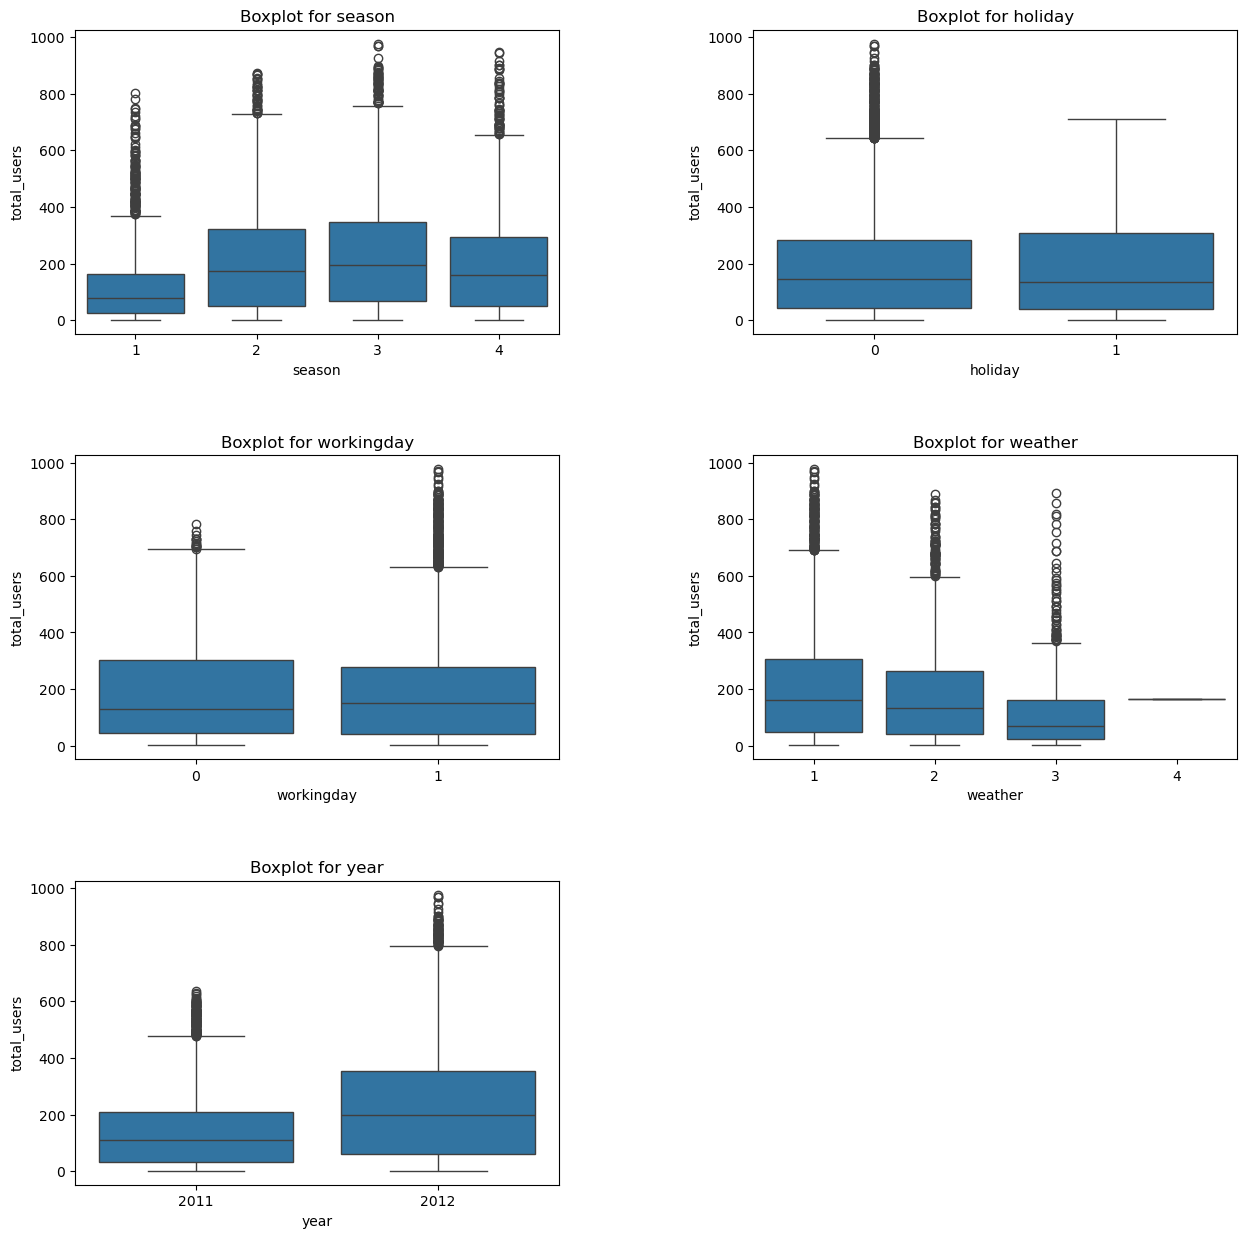

<Figure size 640x480 with 0 Axes>

In [78]:
# Check for outliers
plt.figure(figsize=(15,15))
for i in enumerate(cat_cols):
    plt.subplot(3, 2, i[0] + 1)
    sns.boxplot(x= i[1], y='total_users', data=df)
    plt.title(f"Boxplot for {i[1]}")
plt.subplots_adjust(hspace=0.4, wspace=0.4)
plt.show()
plt.clf()

### 3.2 Univariate Analysis

<div style="background-color: #e6f7ff; padding: 10px;">
    <ul>
        <li>Each group under 'weather' has different count of data points. Group 4 (heavy precipitation) has only one data point.</li>
        <li>Data points for non-working day is less than half (3,474) from working day (7,412).</li>
        <li>Data points for non-holiday is only 311 compared to holiday, with 10,575 data points.</li>
        <li>The rest of the variables have approximate equal data points between groups.</li>
    </ul>
</div>

In [79]:
# Assign all columns' name as a list
cols = ['season', 'weather', 'workingday', 'holiday', 'year', 'month', 'day_of_week']

# Frequency distribution for each column. If it's column 'day', sort according to index
for i in cols:
    if i == 'day':
        print(df[i].value_counts().sort_index())
    else:
        print(df[i].value_counts())
    print()
    print('='*60)
    print()

season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64


weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64


workingday
1    7412
0    3474
Name: count, dtype: int64


holiday
0    10575
1      311
Name: count, dtype: int64


year
2012    5464
2011    5422
Name: count, dtype: int64


month
5     912
6     912
7     912
8     912
12    912
10    911
11    911
4     909
9     909
2     901
3     901
1     884
Name: count, dtype: int64


day_of_week
Sat    1584
Sun    1579
Thu    1553
Mon    1551
Wed    1551
Tue    1539
Fri    1529
Name: count, dtype: int64




<div style="background-color: #e6f7ff; padding: 10px;">
    <ul>
       <li>Further investigation on the single data point of 'heavy precipitation', there are:</li> 
        <ul>
            <li>6 casual users</li>
            <li>158 registered users</li>
            <li>164 total users</li>
        </ul>
    </ul>      
</div>

In [80]:
print(df[df.weather == 4][['casual', 'registered', 'total_users']])

      casual  registered  total_users
5631       6         158          164


<div style="background-color: #e6f7ff; padding: 10px;">
    <ul>
        <li>There is visual difference in counts during the holiday and non-holiday, working day and non-working day.</li>
        <li>In 'weather', category 1 (clear) has the highest count, followed by 2 (misty), 3 (light precipitation), and lastly 4 (heavy precipitation).</li>
        <ul>
            <li>As we found out above, there was only one data point for category 4.</li>
        </ul>
    </ul>
</div>

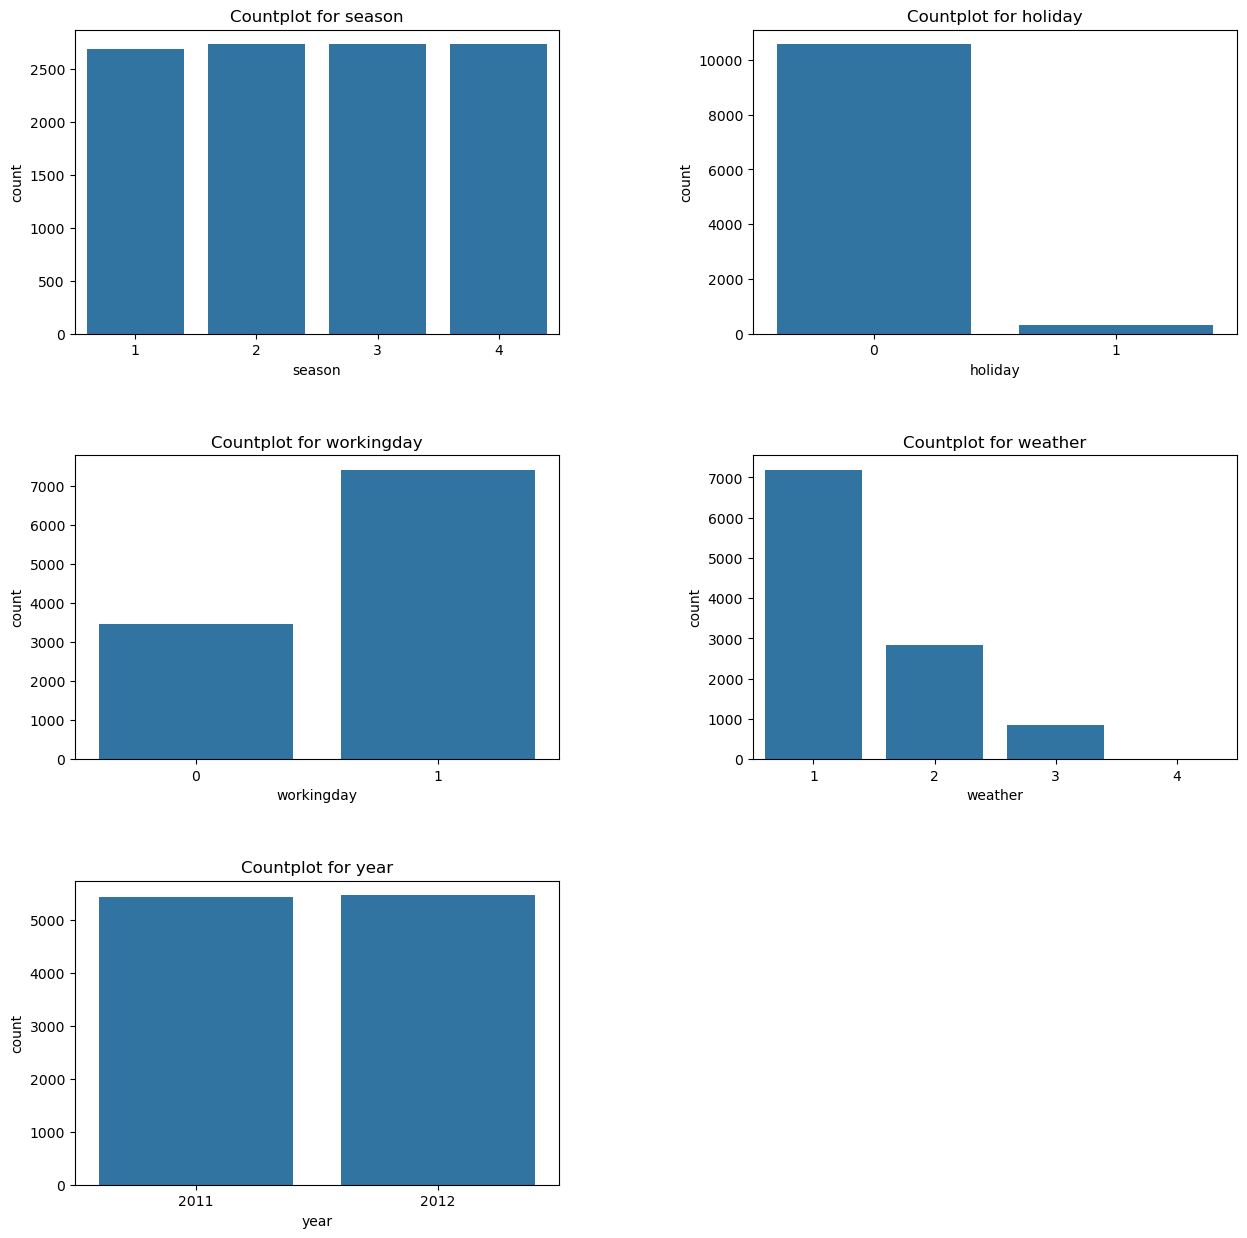

In [81]:
# Countplot for each categorical column
plt.figure(figsize=(15,15))
for i in enumerate(cat_cols):
    plt.subplot(3, 2, i[0] +1)
    sns.countplot(x=i[1], data=df)
    plt.title(f"Countplot for {i[1]}")
plt.subplots_adjust(hspace=0.4, wspace=0.4)
plt.show()

<div style="background-color: #e6f7ff; padding: 10px;">
<b>atemp</b><br>
    <ul>
        <li>The feeling temperature has a range from 0℃ to 45.4℃, an average of 23℃, median of 16.7℃, normally distributed with no outliers.</li>
    </ul>
<b>casual</b><br>
    <ul>
        <li>The casual bike user has a range from 0 to 367, an average of 36, median of 17, positively skewed with outliers.</li>
    </ul>
<b>hour</b><br>
    <ul>
        <li>Hour ranges from 0-23 (24-hour format), with four peak counts at around 0, 7, 15, and 22, normally distributed with no outliers. </li>
    </ul>
<b>humidity</b><br>
    <ul>
        <li>Humidity has a range from 0 to 100, an average of 61.9, median of 62, normally distributed with no outliers.</li>
    </ul>
<b>month</b><br>
    <ul>
        <li>Month ranges from 0-12 (Jan - Dec), normally distributed with no outliers.</li>
    </ul>
<b>registered</b><br>
    <ul>
        <li>Registered users has a range from 0 to 886, an average of 155.6, median of 118, positively skewed with outliers.</li>
    </ul>
<b>temp</b><br>
    <ul>
        <li>Temperature has a range from 0.8℃ to 41℃ , an average of 20.2℃, median of 20.5℃, normally distributed with no outliers.</li>
    </ul>
<b>total_users</b><br>
    <ul>
        <li>Total bike users has a range from 1 to 977, an average of 191.57, median of 145, positively skewed with outliers.</li>
    </ul>
<b>windspeed</b><br>
    <ul>
        <li>Windspeed has a range from 0 to 57, an average of 12.8, median of 13, slightly skewed to the right with outliers. Data is approximately symmetric, but not perfectly normal</li>
    </ul>
</div>

In [82]:
# Setting all numerical columns into one variable
num_cols = df.select_dtypes(include=np.number).columns.difference(['month_sin', 'month_cos', 'hour_sin', 'hour_cos'])

In [83]:
# Define a function to plot histogram, boxplot, and tabulated summary statistics
def hist_box(column):
    plt.figure(figsize=(10,5))
    
    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df[column], bins=20, kde=True)
    plt.title(f"Histogram for {column}")

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(df[column])
    plt.title(f"Boxplot for {column}")

    tabular_data = df[column].describe().reset_index()
    tabular_data.columns = ['Statistics', 'Value']
    display(tabular_data)

    plt.show()
    plt.clf()
    print('-'*120)

,Statistics,Value
0,count,10886.000000
1,mean,23.655084
2,std,8.474601
3,min,0.760000
4,25%,16.665000
5,50%,24.240000
6,75%,31.060000
7,max,45.455000


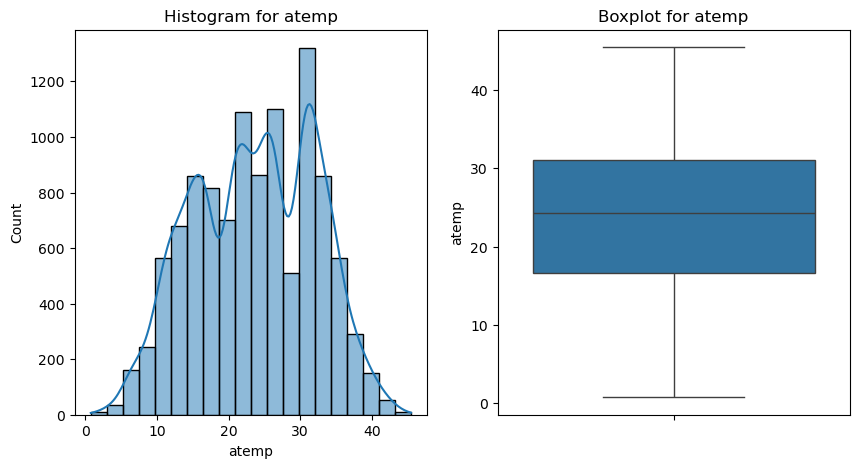

------------------------------------------------------------------------------------------------------------------------


,Statistics,Value
0,count,10886.000000
1,mean,36.021955
2,std,49.960477
3,min,0.000000
4,25%,4.000000
5,50%,17.000000
6,75%,49.000000
7,max,367.000000


<Figure size 640x480 with 0 Axes>

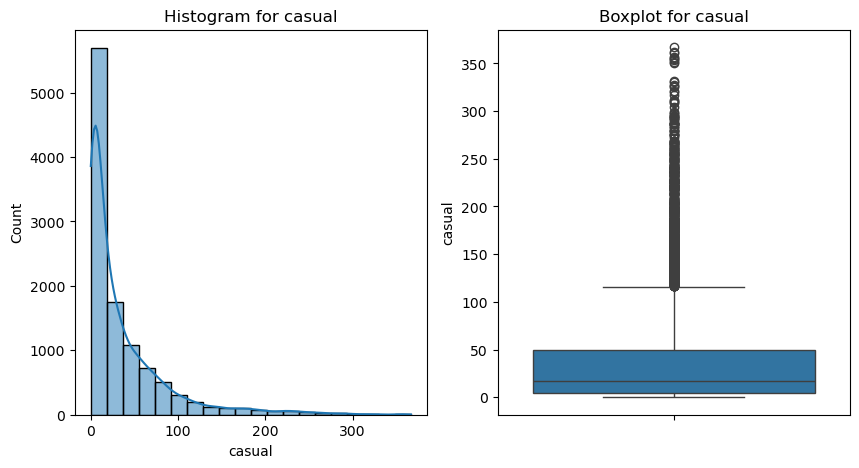

------------------------------------------------------------------------------------------------------------------------


,Statistics,Value
0,count,10886.000000
1,mean,11.541613
2,std,6.915838
3,min,0.000000
4,25%,6.000000
5,50%,12.000000
6,75%,18.000000
7,max,23.000000


<Figure size 640x480 with 0 Axes>

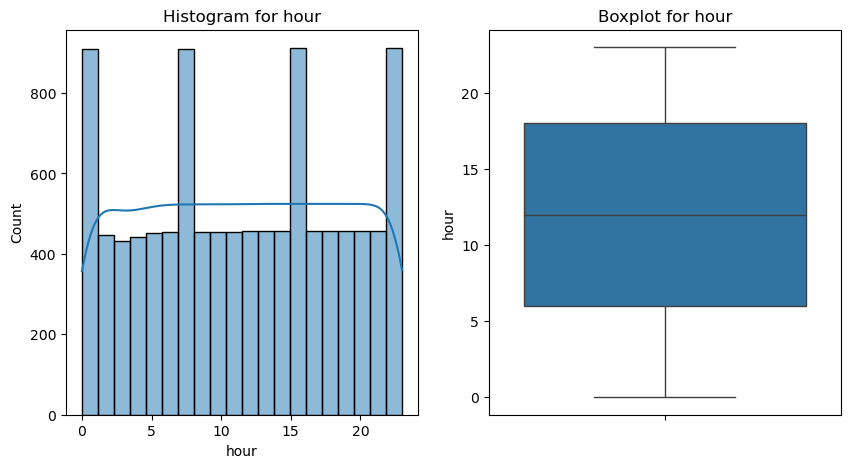

------------------------------------------------------------------------------------------------------------------------


,Statistics,Value
0,count,10886.000000
1,mean,61.886460
2,std,19.245033
3,min,0.000000
4,25%,47.000000
5,50%,62.000000
6,75%,77.000000
7,max,100.000000


<Figure size 640x480 with 0 Axes>

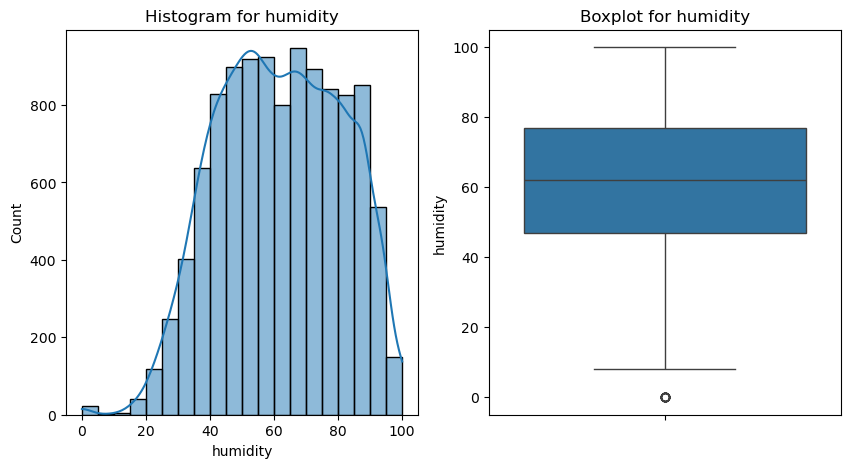

------------------------------------------------------------------------------------------------------------------------


,Statistics,Value
0,count,10886.000000
1,mean,6.521495
2,std,3.444373
3,min,1.000000
4,25%,4.000000
5,50%,7.000000
6,75%,10.000000
7,max,12.000000


<Figure size 640x480 with 0 Axes>

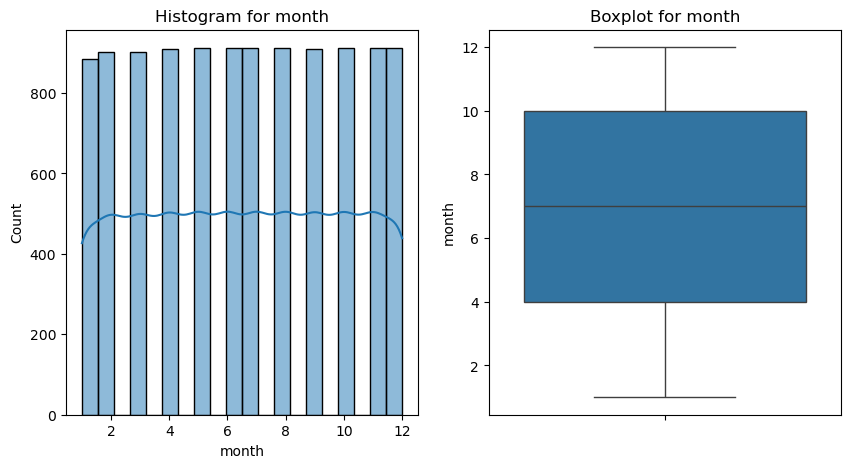

------------------------------------------------------------------------------------------------------------------------


,Statistics,Value
0,count,10886.000000
1,mean,155.552177
2,std,151.039033
3,min,0.000000
4,25%,36.000000
5,50%,118.000000
6,75%,222.000000
7,max,886.000000


<Figure size 640x480 with 0 Axes>

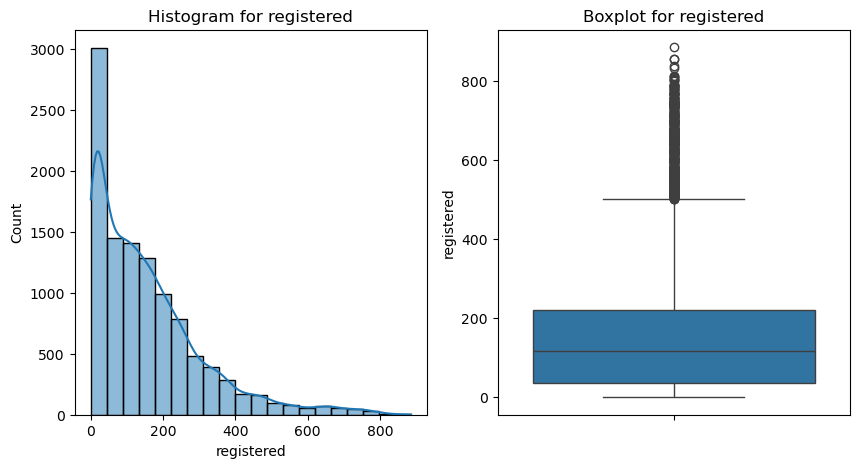

------------------------------------------------------------------------------------------------------------------------


,Statistics,Value
0,count,10886.00000
1,mean,20.23086
2,std,7.79159
3,min,0.82000
4,25%,13.94000
5,50%,20.50000
6,75%,26.24000
7,max,41.00000


<Figure size 640x480 with 0 Axes>

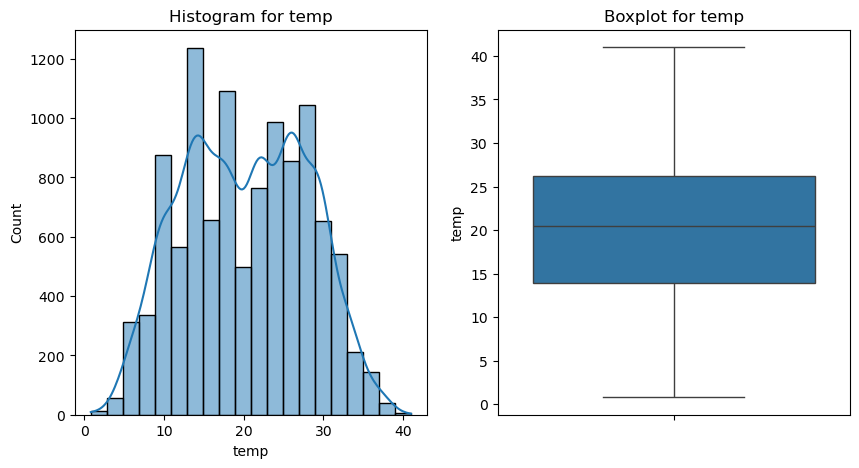

------------------------------------------------------------------------------------------------------------------------


,Statistics,Value
0,count,10886.000000
1,mean,191.574132
2,std,181.144454
3,min,1.000000
4,25%,42.000000
5,50%,145.000000
6,75%,284.000000
7,max,977.000000


<Figure size 640x480 with 0 Axes>

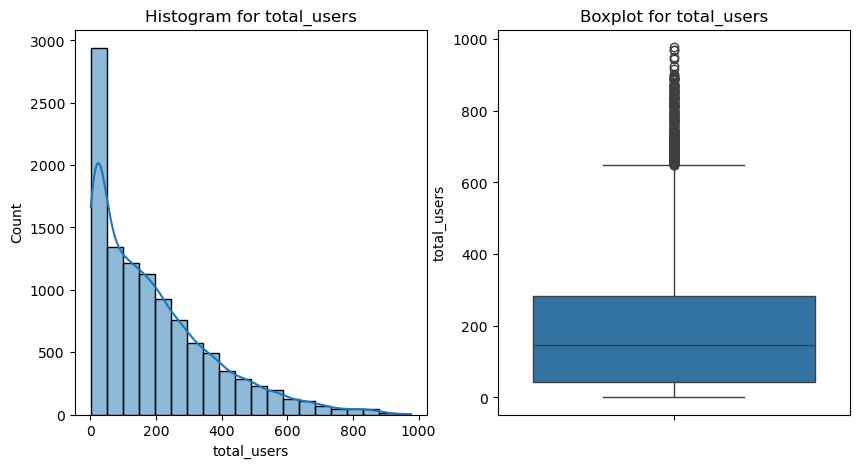

------------------------------------------------------------------------------------------------------------------------


,Statistics,Value
0,count,10886.000000
1,mean,12.799395
2,std,8.164537
3,min,0.000000
4,25%,7.001500
5,50%,12.998000
6,75%,16.997900
7,max,56.996900


<Figure size 640x480 with 0 Axes>

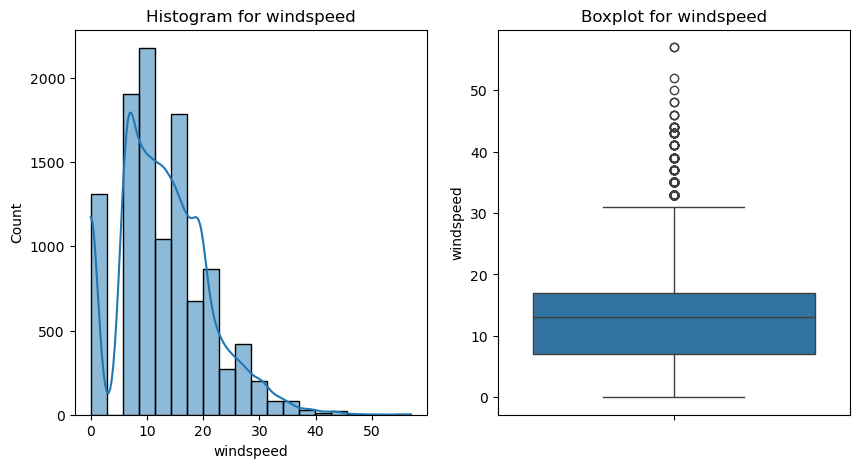

------------------------------------------------------------------------------------------------------------------------


<Figure size 640x480 with 0 Axes>

In [84]:
# Run the function in a loop for numerical columns
for column in num_cols:
    hist_box(column)

### 3.3 Bivariate Analysis

In [85]:
# Reassigning num_cols to exclude 'casual' and 'registered' for further analysis
num_cols = df.select_dtypes(include=np.number).columns.difference(['year', 'month', 'month_sin', 'month_cos', 'day_of_week', 'hour', 'hour_sin', 'hour_cos', 'casual', 'registered', 'total_users'])

#### 3.3.1 Relations Between Continuous Variables and  Total Users

<div style="background-color: #e6f7ff; padding: 10px;">
<b>temp vs total_users</b><br>
<ul>
    <li>Regression shows that there is an increasing trend of total users as the temperature goes higher. This however could be misdirecting.</li>
    <ul>
        <li>Typically, bike usage increases with warmth until an optimal comfort zone (around 20-30℃), then declines when it gets too hot.</li>
        <li>Since the maximum value of 'temp' is at 41℃, the analysis is limited and I was not able to visualize the declines.</li>
    </ul>
    <li>Based on the histogram: </li>
    <ul>
        <li>The highest density of data recorded is at around 10℃, with low total users.</li>
        <li>The bins are showing a positive correlation trend, where as the temperature increases, total users also increase.</li>
        <li>Most data recorded are at lower temperature (<30℃). The data frequency with higher total users are lesser in warmer temperature (>30℃).</li>
        <li>Between 15℃-25℃, the user counts spread widely.</li>
        <ul>
            <li>Despite this, the average total users per bin seems to be higher, and it drops around 40℃.</li>
        </ul>
    <li>Linear regression is possible for further statistical analysis.</li>
    </ul>
</ul>
    
<b>atemp vs total_users</b><br>
<ul>
    <li>Regression shows that there is an overall increasing trend of total users as the apparent temperature goes higher. Similar to temp, this could be misdirecting due to limitation of data.</li>
    <li>Based on the histogram:</li>
    <ul>
        <li>The highest density of data recorded is at between 20℃-25℃, with low total users.</li>
        <li>The bins are showing positive correclation trend, as the apparent temperature increases, total users also increase. </li>
        <li>Most data recorded at lower apparent temperature (<35℃). The data frequency with higher total users are lesser in warmer temperature (>35℃).</li>
        <li>Between 25℃-35℃, the user counts spread widely.</li>
        <ul>
            <li>Despite having less data frequency, the average total users seems to be higher temperature, up to 40℃.</li>
        </ul>  
    </ul>
    <li>Linear regression is possible for further statistical analysis.</li>
</ul>

<b>humidity vs total_users</b><br>
<ul>
    <li>Regression shows there is an overall decreasing trend of total users as the humidity increases. 
    <li>Based on the histogram:</li>
    <ul>
        <li>The highest density of data recorded is at between 80-100% humidity, with low total users.</li>
        <li>The bins are showing negative correlation trend, as the humidity increases, the total users decrease.</li>
        <li>Less data were recorded at lower humidity (<40%), and more were recorded at higher humidity (>40%).</li>
        <li>Between 30-70% humidity, the user counts spread widely.</li>
    </ul>
    <li>Linear regression is possible for further statistical analysis.</li>
</ul>
    
<b>windspeed vs total_users</b><br>
<ul>
    <li>Regression shows a flat line as the wind speed increases, signifying there is no relations between total users and windspeed.</li>
    <li>Based on the histogram:</li>
    <ul>
        <li>The histogram shows the data recorded are mostly at lower wind speed.</li>
    </ul>
    <li>Since wind speed has no relations with the total users, it will be excluded from further statistical analysis.</li>
</ul>
</div>

In [86]:
# Define a function for scatter plot, binned statistic, and histogram
def scatter_hist(num_col):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    # Scatter plot
    sns.scatterplot(x=num_col, y='total_users', data=df, ax=axes[0])
    sns.regplot(x=num_col, y='total_users', data=df, scatter=True, lowess=True, line_kws={'color':'red'}, ax=axes[0])
    axes[0].set_title(f"Scatter plot: {num_col} vs total_users")

    # Histogram
    x=df[num_col]
    y=df['total_users']
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    x_bins = 30
    y_bins = 30
    h = axes[1].hist2d(x, y, bins=[x_bins, y_bins], range=[[x_min, x_max], [y_min, y_max]], cmap='Blues')
    fig.colorbar(h[3], ax=axes[1], label='Counts')

    bin_means, bin_edges, _ = binned_statistic(x, y, statistic='mean', bins=x_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) /2

    axes[1].plot(bin_centers, bin_means, color='red', marker='o', label='Average per bin')
    axes[1].legend()
    
    axes[1].set_xlabel(num_col)
    axes[1].set_ylabel('Total Users')
    axes[1].set_title(f"Bivariate histogram: {num_col} vs total_users")

    plt.tight_layout()
    plt.show()

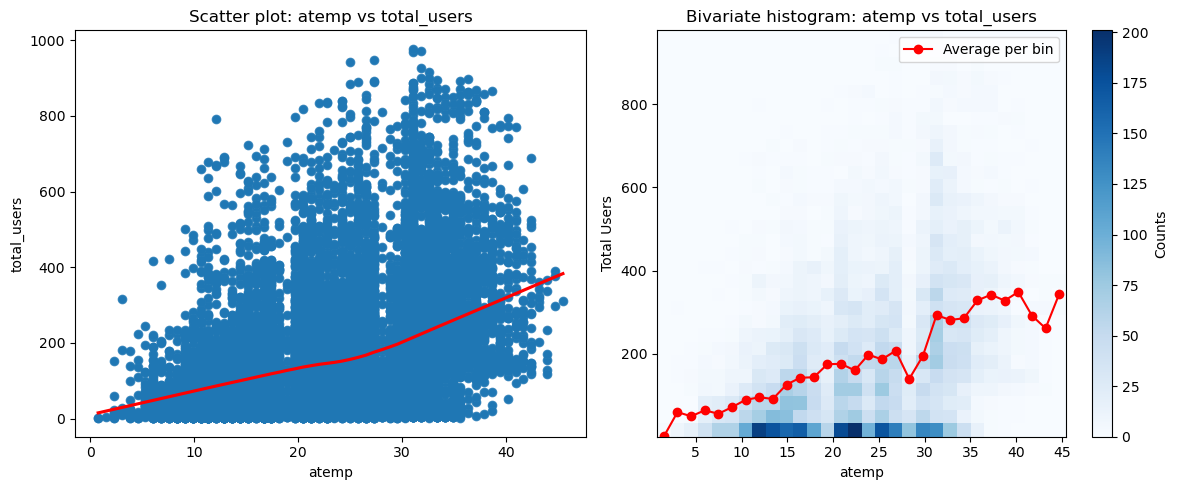

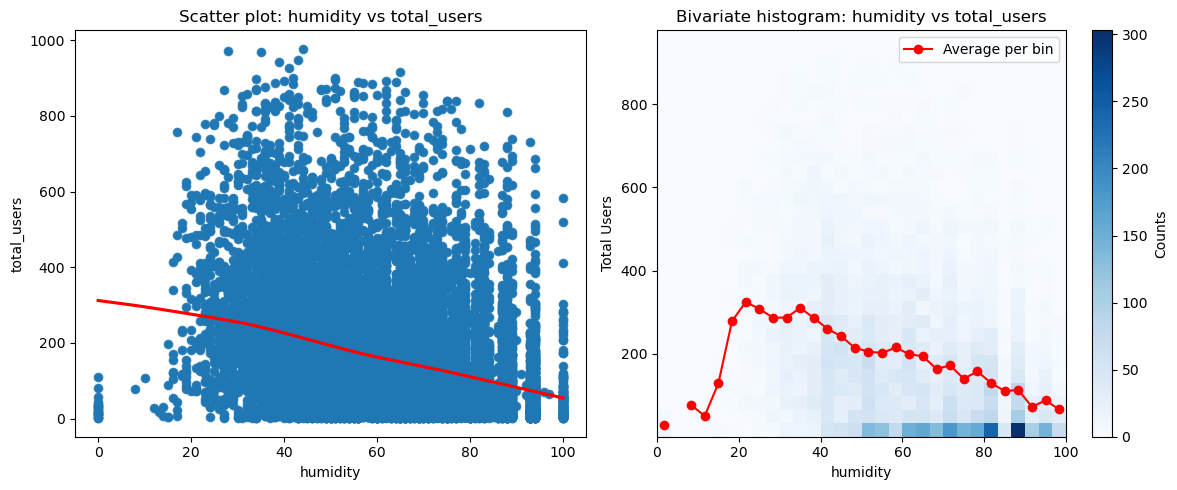

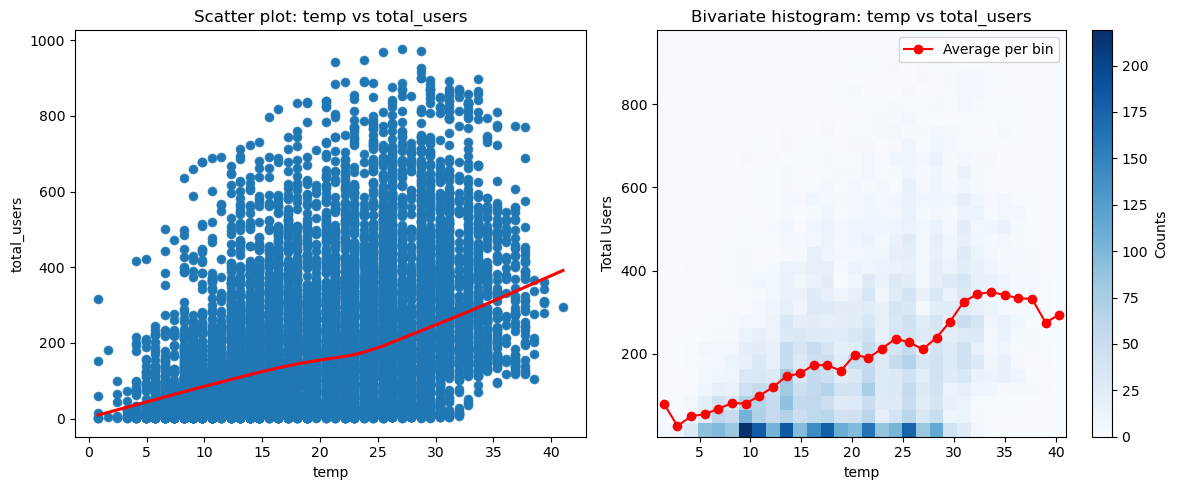

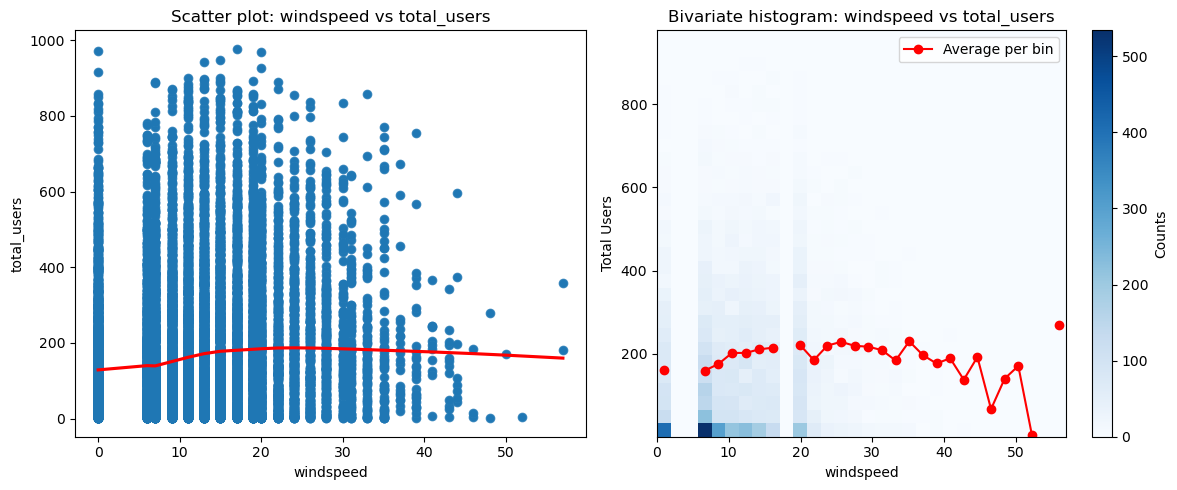

In [87]:
for num_col in num_cols:
    scatter_hist(num_col)

#### 3.3.2 Relations Between Categorical Variables and Total Users

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>In general, all categories exhibit similar patterns of having outliers, positively skewed, highly varied (CV >0.8).</li>
    <li>Exceptions are, holidays are the only consistent pattern, where there are no outliers. Another one is 'weather' category 4 has a line instead of a boxplot, as previously mentioned, has only one data point.</li>
    <li>Having highest mean and median doesn't mean the category is significant in the outcome of bike users.</li>
    <li>The CV are all >0.8, signifying imbalance of total users in each category.</li>
    <ul>
        <li>This indicates that the data's spread is large relative to the mean.</li>
        <li>Futher inferential tests are required to determine if a category is significant.</li>
        <li>High variability also suggests high heterogeneity. This breaks assumptions of normality and equal variance required for parametric tests.</li>
    </ul>
</ul>

In [88]:
# Summary table of categorical columns
for cat_col in cat_cols:
    stats = df.groupby(cat_col)['total_users'].agg(['mean', 'median', 'std'])
    stats['cv'] = stats['std'] / stats['mean']
    print(stats)

              mean  median         std        cv
season                                          
1       116.343261    78.0  125.273974  1.076762
2       215.251372   172.0  192.007843  0.892017
3       234.417124   195.0  197.151001  0.841026
4       198.988296   161.0  177.622409  0.892627
               mean  median         std        cv
holiday                                          
0        191.741655   145.0  181.513131  0.946655
1        185.877814   133.0  168.300531  0.905436
                  mean  median         std        cv
workingday                                          
0           188.506621   128.0  173.724015  0.921580
1           193.011873   151.0  184.513659  0.955971
               mean  median         std        cv
weather                                          
1        205.236791   161.0  187.959566  0.915818
2        178.955540   134.0  168.366413  0.940828
3        118.846333    71.0  138.581297  1.166054
4        164.000000   164.0         NaN     

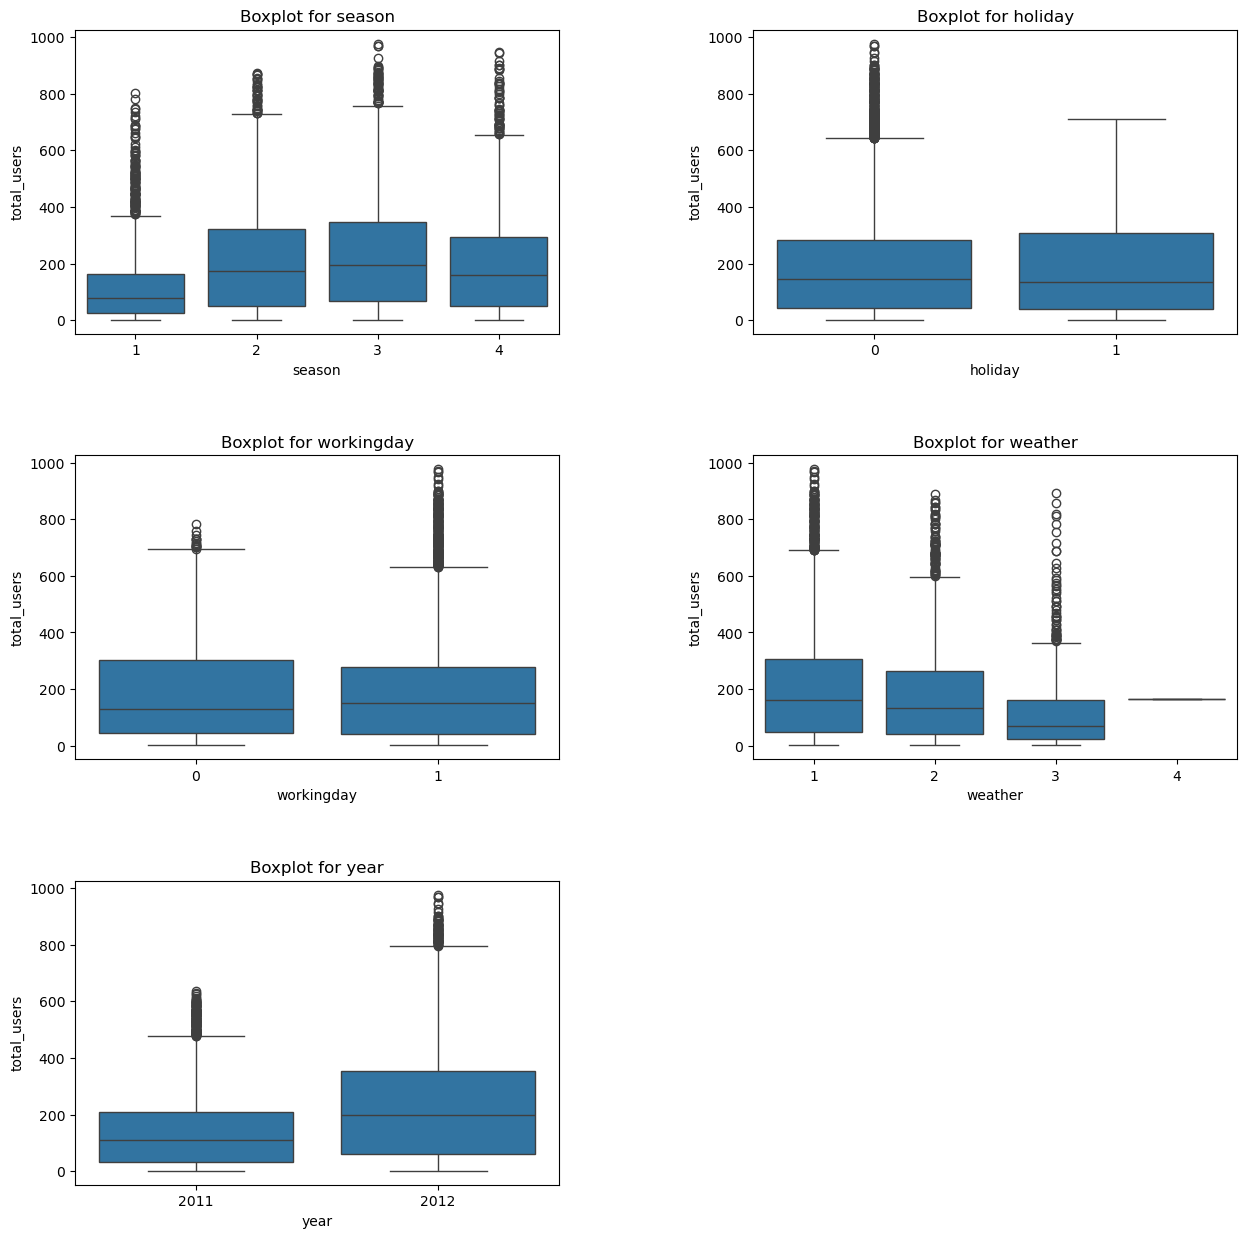

<Figure size 640x480 with 0 Axes>

In [89]:
plt.figure(figsize=(15,15))
for i in enumerate(cat_cols):
    plt.subplot(3, 2, i[0] + 1)
    sns.boxplot(x= i[1], y='total_users', data=df)
    plt.title(f"Boxplot for {i[1]}")
plt.subplots_adjust(hspace=0.4, wspace=0.4)
plt.show()
plt.clf()

#### 3.3.3 Relations Between Datetime And Total Users

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>2012 has the highest average total users (~238), 2011 has the lowest average total users (~144).</li>
    <li>June has the highest average total users (~242), January has the lowest average total users (~90).</li>
    <li>Thursday, Friday, Saturday have the highest average total users in a week, with roughly equal value (~196), Sunday has the lowest average total users in a week (~180).</li>
    <li>The highest average users by hour of the day is 5pm (~468). Lowest is at 4am (~6).</li>
</ul> 
</div>

In [90]:
# Assign all datetime variables into a list
datetime_cols = ['year', 'month', 'day_of_week', 'hour']

year
2011    144.223349
2012    238.560944
Name: total_users, dtype: float64


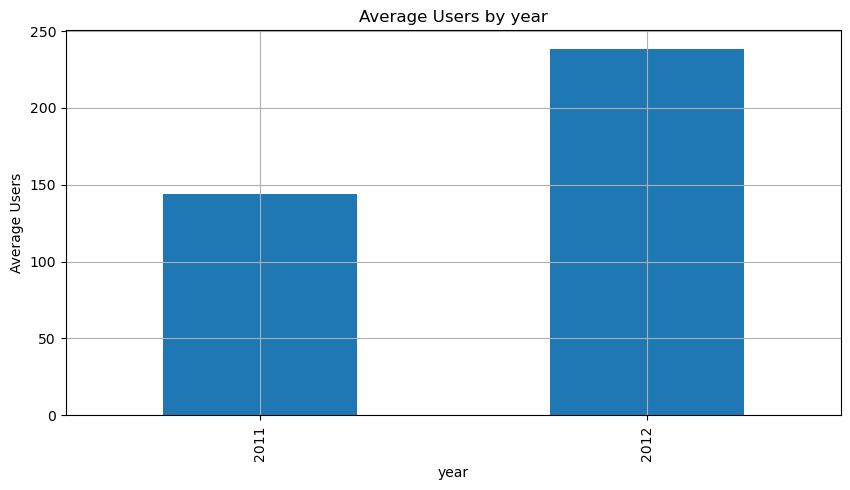

month
1      90.366516
2     110.003330
3     148.169811
4     184.160616
5     219.459430
6     242.031798
7     235.325658
8     234.118421
9     233.805281
10    227.699232
11    193.677278
12    175.614035
Name: total_users, dtype: float64


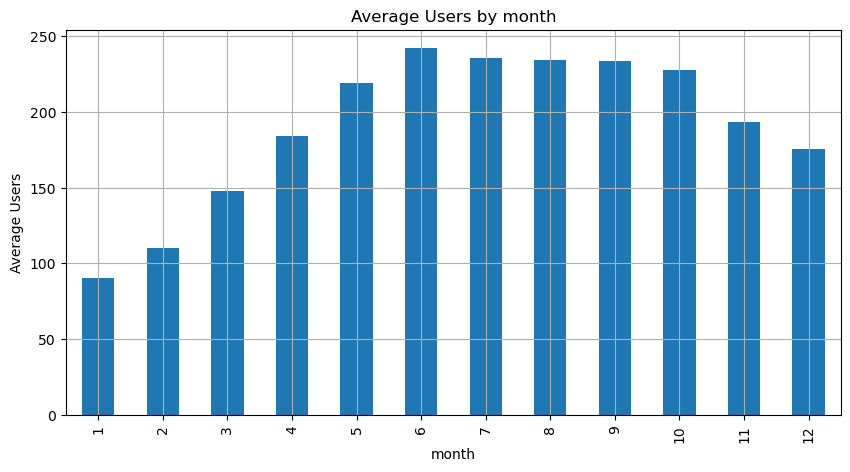

day_of_week
Mon    190.390716
Tue    189.723847
Wed    188.411348
Thu    197.296201
Fri    197.844343
Sat    196.665404
Sun    180.839772
Name: total_users, dtype: float64


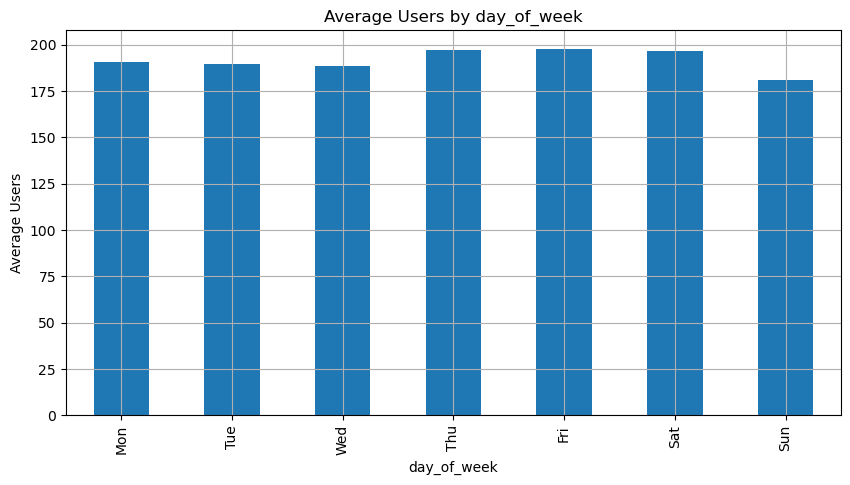

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total_users, dtype: float64


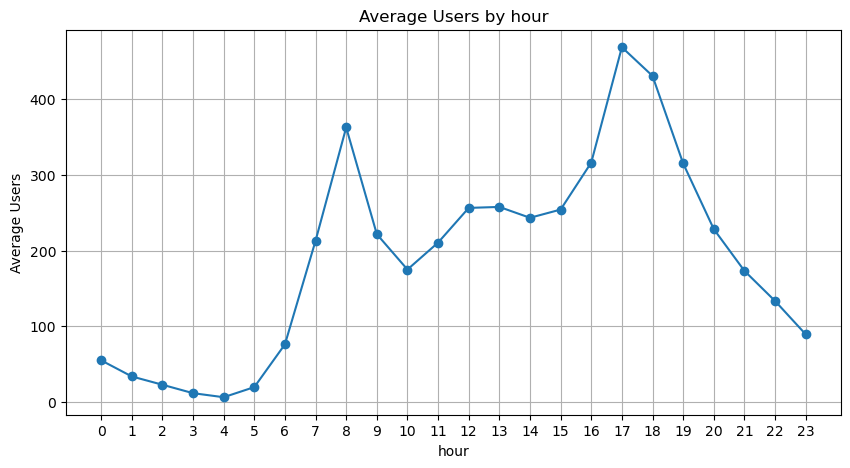

In [91]:
for datetime_col in datetime_cols:
    avg_users = df.groupby(datetime_col)['total_users'].mean()
    print(avg_users)
    plt.figure(figsize=(10,5))
    if datetime_col in ['day_of_week', 'month', 'year']:
        avg_users.plot(kind='bar')
    else:
        avg_users.plot(kind='line', marker='o')
        plt.xticks(range(0,24))
    plt.title(f"Average Users by {datetime_col}")
    plt.xlabel(f"{datetime_col}")
    plt.ylabel("Average Users")
    plt.grid(True)
    plt.show()
    plt.close()

## 4. STATISTICAL ANALYSIS

### 4.1 Categorical Variables

#### 4.1.1 Two Sample T-Tests

<div style="background-color: #e6f7ff; padding: 10px;">
    <ul>
        <li>Two samples t-test is used to determine whether the means of two independent groups are significantly different from each other.</li>
        <li>There are two binary categorical variables in the dataframe: 'holiday' and 'workingday'.</li>
        <li>The significance threshold is set at 0.05.</li>
    </ul>
<b>Findings</b><br>
    <ul>
        <li>The average total users for both groups under 'holiday' and 'workingday' are not statistically different from one another.</li>
    </ul>
</div>

In [92]:
binaries = ['holiday', 'workingday']

In [93]:
def ttest_hist(binary):
    # Two samples t-test
    print(f"""
    Null hypothesis: The average number of bike users of groups under the column '{binary}' are equal.
    Alternative hypothesis : The average number of bike users of groups under the column '{binary}' are different.
    """)

    ones = df['total_users'][df[binary] == 1]
    zeroes= df['total_users'][df[binary] == 0]
    tstat, pval = ttest_ind(ones, zeroes)
    print(f"p-value: {pval:.3f}")
    if pval < 0.05:
        print(f"p-value < 0.05, there is a significant difference in average total bike users of groups under the column '{binary}'. Thus we reject null hypothesis.")
    else:
        print(f"p-value > 0.05, there is no significant difference in average total bike users of groups under the column '{binary}'. Thus we failed to reject null hypothesis.")

    # Histogram
        # plt.hist(ones, alpha=0.5, label=f"{binary}=1")
        # plt.hist(zeroes, alpha=0.5, label=f"{binary}=0")
        # plt.xlabel(binary)
        # plt.ylabel(f"Total Users")
        # plt.legend()
        # plt.title(f"Distribution of total users by {binary}")
        # plt.show()
        # plt.clf()

In [94]:
for binary in binaries:
    ttest_hist(binary)


    Null hypothesis: The average number of bike users of groups under the column 'holiday' are equal.
    Alternative hypothesis : The average number of bike users of groups under the column 'holiday' are different.
    
p-value: 0.574
p-value > 0.05, there is no significant difference in average total bike users of groups under the column 'holiday'. Thus we failed to reject null hypothesis.

    Null hypothesis: The average number of bike users of groups under the column 'workingday' are equal.
    Alternative hypothesis : The average number of bike users of groups under the column 'workingday' are different.
    
p-value: 0.226
p-value > 0.05, there is no significant difference in average total bike users of groups under the column 'workingday'. Thus we failed to reject null hypothesis.


#### 4.1.2 Welch's ANOVA and Games-Howell Post-hoc Test

<div style="background-color: #e6f7ff; padding: 10px;">
    <ul>
        <li>There are two non-binary categorical variables in the dataset; 'season' and 'weather', grouped based on users: 'casual', 'registered', and 'total_users'.</li>
        <li>Significance threshold is set at 0.05.</li>
        <li>Through Levene's test, the variance between these groups are proven statistically different. Normal assumptions of standard ANOVA are not met. Welch's ANOVA were used instead.</li>
        <li>Games-Howell post-hoc test are used to identify specific pairs of groups that are statistically different from each other, especially when the assumptions of equal variances or equal sample sizes are not met.</li>
        <li>All groups' average total users under 'season' are statistically different from one another.</li>
        <li>Category 4 of column 'weather' has only one data point. Post-hoc test is not able to look for statistical difference with the other category.</li>
        <li>Under column 'weather', the pairs 1-2, 1-3, and 2-3 have statistically different average total users.</li>
    </ul>
</div>

In [131]:
# Assign non-binary categorical column's name as a list
non_binaries = ['season', 'weather']

In [132]:
# Welch's ANOVA, Levene's test, and bar plot
def anova_posthoc_bar(non_binary):
    # ANOVA
    print(f"""
    Null hypothesis: The average bike users across all groups under column '{non_binary}' are equal.
    Alternative hypothesis: The average bike users across groups under column '{non_binary}' are different.
    """)
    # for user in users:
    groups = []
    for category in df[non_binary].unique():
        group = df['total_users'][df[non_binary] == category]
        groups.append(group)
        group_var = np.var(group)
        print(f"Variance for {category}: {group_var:.3f}")
    print('-'*55) 
    
    stat, p = levene(*groups)
    print(f"Levene's test p-value: {p:.10f}")
    if p < 0.05:
        print(f"Levene's p < 0.05. There is a significant difference in variance between groups. Normal assumptions for standard ANOVA aren't met. Proceed with Welch's ANOVA instead.")
    else:
        print(f"Levene's p > 0.05. There is no significant difference in variance between groups. Normal assumptions for standard ANOVA are met. Proceed with standard ANOVA.")

    # Welch's ANOVA
    result = pg.welch_anova(dv='total_users', between=non_binary, data=df)
    p_value = result['p_unc'][0]
    print(f"Welch's p-value: {p_value}")
    if p_value < 0.05:
        print(f"p-value < 0.05. There is at least one pair of groups that is statistically different from each other. Proceed with Games-Howell post-hoc test.")
    else:
        print(f"p-value > 0.05. There is not a pair that is statistically different from each other. Post-hoc test is not required.")
    
    # Games-Howell post-hoc test
    result = pg.pairwise_gameshowell(dv='total_users', between=non_binary, data=df)
    print(result)

    # Bar plot
    plt.bar(non_binary, 'total_users', data=df)
    if non_binary == 'season':
        plt.xticks(ticks=[1.0, 2.0, 3.0, 4.0], labels=['spring', 'summer', 'fall', 'winter'])
    else:
        plt.xticks(ticks=[1.0, 2.0, 3.0, 4.0], labels=['clear', 'misty', 'light precipitation', 'heavy precipitation'], rotation=20)
    plt.xlabel(f"{non_binary}")
    plt.ylabel(f"Count of total users")
    plt.show()
    plt.clf()
    print('-'*120)


    Null hypothesis: The average bike users across all groups under column 'season' are equal.
    Alternative hypothesis: The average bike users across groups under column 'season' are different.
    
Variance for 1: 15687.726
Variance for 2: 36853.522
Variance for 3: 38854.295
Variance for 4: 31538.181
-------------------------------------------------------
Levene's test p-value: 0.0000000000
Levene's p < 0.05. There is a significant difference in variance between groups. Normal assumptions for standard ANOVA aren't met. Proceed with Welch's ANOVA instead.
Welch's p-value: 4.844999392897717e-201
p-value < 0.05. There is at least one pair of groups that is statistically different from each other. Proceed with Games-Howell post-hoc test.
   A  B      mean_A      mean_B        diff        se          T           df  \
0  1  2  116.343261  215.251372  -98.908111  4.396852 -22.495212  4711.743230   
1  1  3  116.343261  234.417124 -118.073863  4.479358 -26.359548  4640.865715   
2  1  4 

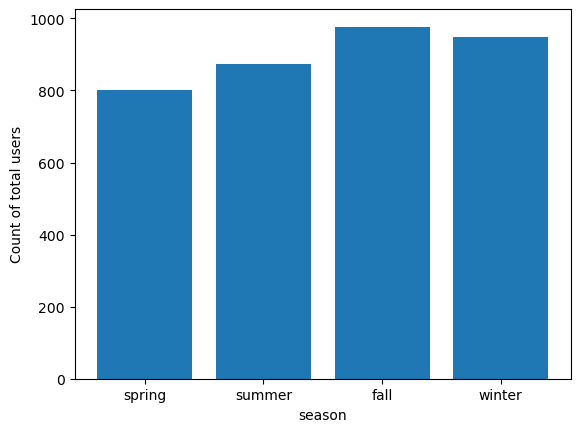

------------------------------------------------------------------------------------------------------------------------

    Null hypothesis: The average bike users across all groups under column 'weather' are equal.
    Alternative hypothesis: The average bike users across groups under column 'weather' are different.
    
Variance for 1: 35323.886
Variance for 2: 28337.246
Variance for 3: 19182.419
Variance for 4: 0.000
-------------------------------------------------------
Levene's test p-value: 0.0000000000
Levene's p < 0.05. There is a significant difference in variance between groups. Normal assumptions for standard ANOVA aren't met. Proceed with Welch's ANOVA instead.
Welch's p-value: 5.349498477826607e-59
p-value < 0.05. There is at least one pair of groups that is statistically different from each other. Proceed with Games-Howell post-hoc test.
   A  B      mean_A      mean_B       diff        se          T           df  \
0  1  2  205.236791  178.955540  26.281251  3.861968 

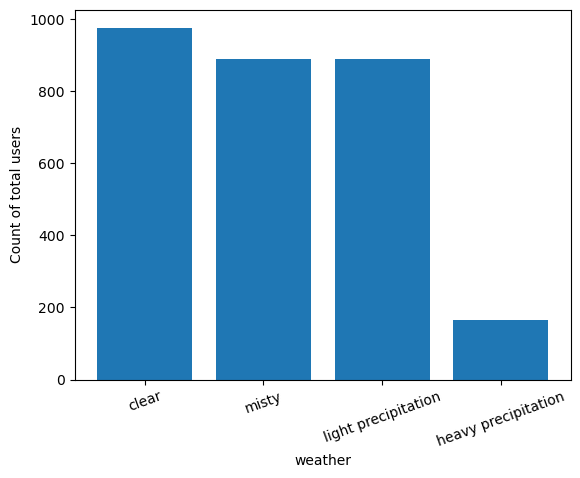

------------------------------------------------------------------------------------------------------------------------


<Figure size 640x480 with 0 Axes>

In [133]:
# Run the function in a loop for non-binary categorical columns
for non_binary in non_binaries:
    anova_posthoc_bar(non_binary)

### 4.2 Continuous Variables

#### 4.2.1 Pearson Correlations

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>Both 'temp' and 'atemp' has a moderate positive correlation against 'total_users'. This means as the temperature or apparent temperature increases, the total users also increase.</li>
    <li>'humidity' has a moderate negative correlation against 'total_users'. This means as the humidity increases, the total users decrease.</li>
    <li>'windspeed' has a very weak positive correlation against 'total_users'. Wind speed doesnt appear to affect total users.</li>
</ul>
</div>

In [98]:
continuous_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'total_users']
df_cont = df[continuous_cols]
corr_matrix = df_cont.corr(method='pearson')
print(corr_matrix)

                 temp     atemp  humidity  windspeed  total_users
temp         1.000000  0.984948 -0.064949  -0.017852     0.394454
atemp        0.984948  1.000000 -0.043536  -0.057473     0.389784
humidity    -0.064949 -0.043536  1.000000  -0.318607    -0.317371
windspeed   -0.017852 -0.057473 -0.318607   1.000000     0.101369
total_users  0.394454  0.389784 -0.317371   0.101369     1.000000


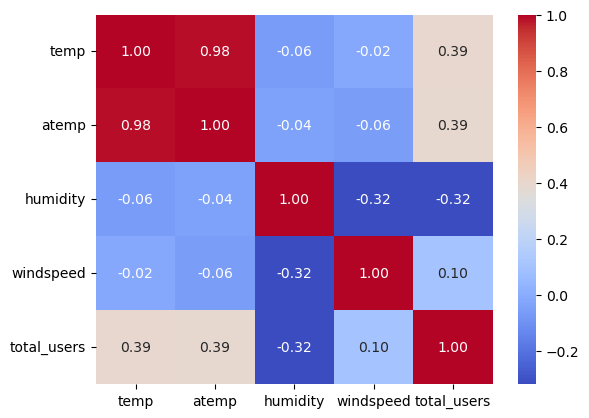

In [99]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()
plt.close()

## 5. MODELING

### 5.1 Baseline Regression

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>One-Hot Encoding were applied to non-binary categorical variables. The first group was dropped, setting a baseline category to be compared to, preventing perfect multicollinearity and inflation of variance.</li>
    <li>'weather_4' (heavy precipitation) is excluded from the regression because of insufficient data points.</li>
</ul>
</div>

In [100]:
# OHE non-binary categorical variables
df_encoded = pd.get_dummies(df, columns=['season', 'weather'], drop_first=True)
day_dummies = pd.get_dummies(df['day_of_week'], prefix='dow', drop_first=True)
df_encoded = pd.concat([df_encoded, day_dummies], axis=1)

df_encoded.dtypes

# Convert into 'integer' data type
to_int_cols = ['workingday', 'holiday', 'season_2', 'season_3', 'season_4', 'weather_2', 'weather_3', 'year', 'dow_Tue', 'dow_Wed', 'dow_Thu', 'dow_Fri', 'dow_Sat', 'dow_Sun']
df_encoded[to_int_cols] = df_encoded[to_int_cols].astype('int')

# Check on data types before regression
print(df_encoded.dtypes)

datetime       datetime64[us]
holiday                 int64
workingday              int64
temp                  float64
atemp                 float64
humidity                int64
windspeed             float64
casual                  int64
registered              int64
total_users             int64
year                    int64
month                   int64
day_of_week          category
hour                    int32
hour_sin              float64
hour_cos              float64
month_sin             float64
month_cos             float64
season_2                int64
season_3                int64
season_4                int64
weather_2               int64
weather_3               int64
weather_4               int64
dow_Tue                 int64
dow_Wed                 int64
dow_Thu                 int64
dow_Fri                 int64
dow_Sat                 int64
dow_Sun                 int64
dtype: object


<div style="background-color: #e6f7ff; padding: 10px">
<ul>
    <li>Based on this OLS regression results, by looking at 'workingday', 'holiday', 'dow_Sat', and 'dow_Sun', the coef and std err are very high, suggesting collinearity issues.</li>
    <li>High Condition Number also indicates multicollinearity.</li>
</ul>
</div>

In [101]:
X_full = df_encoded[
    ['temp', 'humidity', 'windspeed', 'workingday', 'holiday', 'year', 'weather_2', 'weather_3']
    + list(df_encoded.filter(like='season_'))
    + list(df_encoded.filter(like='month_'))
    + list(df_encoded.filter(like='dow_'))
    + list(df_encoded.filter(like='hour_'))
]             
y = df_encoded['total_users']

X_full = sm.add_constant(X_full)
model_full = sm.OLS(y, X_full).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:            total_users   R-squared:                       0.512
Model:                            OLS   Adj. R-squared:                  0.511
Method:                 Least Squares   F-statistic:                     599.1
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:59:18   Log-Likelihood:                -68145.
No. Observations:               10886   AIC:                         1.363e+05
Df Residuals:                   10866   BIC:                         1.365e+05
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.463e+05   3971.414    -36.827      0.0

### 5.2  Stage 1 Diagnostics & Model Refinement

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>The 'divide by zero' warning in VIF calculations may signify perfect or near-perfect collinearity. One of the variables is redundant.</li>
    <li>The variables suspected are 'workingday', 'holiday', 'dow_Sat', and 'dow_Sun'.</li>
</ul>
</div>

In [102]:
X_full = sm.add_constant(X_full)
vif = pd.DataFrame()
vif['Variable'] = X_full.columns
vif['VIF'] = [variance_inflation_factor(X_full.values, i) for i in range(X_full.shape[1])]

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>The variables that caused 'divide by error' are:</li>
    <ul>
        <li>'workingday'</li>
        <li>'holiday'</li>
        <li>'month_sin'</li>
        <li>'month_cos'</li>
        <li>'dow_Sat'</li>
        <li>'dow_Sun'</li>
    </ul>
    <li>'dow_Sat' and 'dow_Sun' remains because I am dropping 'workingday' and 'holiday' to avoid redundancy.</li>
    <li>'month_sin' and 'month_cos' will be dropped too. Instead, I am going to OHE 'month' into categorical variable.</li>
</ul>
</div>

In [103]:
# To identify which variable is causing VIF error above
X_full = sm.add_constant(X_full)

for i, col in enumerate(X_full.columns):
    try:
        vif_val = variance_inflation_factor(X_full.values, i)
        print(col, vif_val)
    except Exception as e:
        print(col, "error:", e)

C:\Users\User\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\User\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


const 0.0
temp 4.699373308168205
humidity 1.8378641957625124
windspeed 1.17590255643165
workingday inf
holiday inf
year 1.03234393112349
weather_2 1.1752814922791592
weather_3 1.2672024402264255
season_2 3.4046593586046794
season_3 4.291453436908347
season_4 3.0065166311484983
month_sin inf
month_cos inf
dow_Tue 1.8307938617853512
dow_Wed 1.8184465043954217
dow_Thu 1.844300831724256
dow_Fri 1.789440269871379
dow_Sat inf
dow_Sun inf
hour_sin 1.4119225713686698
hour_cos 1.2407283725364446


<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>Instead of cyclical encode 'month', I decided to convert into categorical using OHE.</li>
</ul>
</div>

In [104]:
# OHE variable 'month'
month_dummies = pd.get_dummies(df['month'], prefix='month', drop_first=True).astype('int')
df_encoded = pd.concat([df_encoded, month_dummies], axis=1)

df_encoded.dtypes

datetime       datetime64[us]
holiday                 int64
workingday              int64
temp                  float64
atemp                 float64
humidity                int64
windspeed             float64
casual                  int64
registered              int64
total_users             int64
year                    int64
month                   int64
day_of_week          category
hour                    int32
hour_sin              float64
hour_cos              float64
month_sin             float64
month_cos             float64
season_2                int64
season_3                int64
season_4                int64
weather_2               int64
weather_3               int64
weather_4               int64
dow_Tue                 int64
dow_Wed                 int64
dow_Thu                 int64
dow_Fri                 int64
dow_Sat                 int64
dow_Sun                 int64
month_2                 int64
month_3                 int64
month_4                 int64
month_5   

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>Based on the footnotes, apparrently there is still collinearity issue in the OLS regression result.</li>
    <li>Based on logic, the most probable cause for this is collinearity between 'season' and 'month', since 'season' is just a grouped up months.</li>
    <li>Next course of action is to drop 'season' from the regression.</li>
</ul>
</div>

In [105]:
# Re-run regression, exclude 'workingday', 'holiday', 'month_sin' and 'month_cos'
X_reduced = df_encoded[
    ['temp', 'humidity', 'windspeed', 'year', 'weather_2', 'weather_3']
    + list(df_encoded.filter(like='season_'))
    + [col for col in df_encoded.filter(like='month_').columns
       if col not in ['month_sin', 'month_cos']]
    + list(df_encoded.filter(like='dow_'))
    + list(df_encoded.filter(like='hour_'))
]             
y = df_encoded['total_users']

X_reduced = sm.add_constant(X_reduced)
model_reduced = sm.OLS(y, X_reduced).fit()
print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:            total_users   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     461.0
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:59:21   Log-Likelihood:                -68109.
No. Observations:               10886   AIC:                         1.363e+05
Df Residuals:                   10860   BIC:                         1.365e+05
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.825e+05   4958.518    -36.798      0.0

### 5.3 Stage 2 Diagnostics & Model Refinement 

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>Condition number is large (8.24e+06). This may be because of scaling issue</li>
    <li>This issue may due to mixing continuous and dummy predictors.</li>
    <li>Next course of action is standardize continuous predictors.</li>
</ul>
</div>

In [106]:
# Re-run regression, exclude 'workingday', 'holiday', 'month_sin', 'month_cos', and 'season_'
X_reduced = df_encoded[
    ['temp', 'humidity', 'windspeed', 'year', 'weather_2', 'weather_3']
    + [col for col in df_encoded.filter(like='month_').columns
       if col not in ['month_sin', 'month_cos']]
    + list(df_encoded.filter(like='dow_'))
    + list(df_encoded.filter(like='hour_'))
]             
y = df_encoded['total_users']

X_reduced = sm.add_constant(X_reduced)
model_reduced = sm.OLS(y, X_reduced).fit()
print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:            total_users   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     461.0
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:59:21   Log-Likelihood:                -68109.
No. Observations:               10886   AIC:                         1.363e+05
Df Residuals:                   10860   BIC:                         1.365e+05
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.825e+05   4958.518    -36.798      0.0

In [107]:
# Standardize continuous predictors
scaler = StandardScaler()
df_encoded[['temp', 'humidity', 'windspeed', 'year']] = scaler.fit_transform(
    df_encoded[['temp', 'humidity', 'windspeed', 'year']]
)

# Check VIF
X_reduced = sm.add_constant(X_reduced)
vif = pd.DataFrame()
vif['Variable'] = X_reduced.columns
vif['VIF'] = [variance_inflation_factor(X_reduced.values, i) for i in range(X_reduced.shape[1])]
print(vif)

     Variable           VIF
0       const  1.677418e+07
1        temp  5.685620e+00
2    humidity  1.937827e+00
3   windspeed  1.190362e+00
4        year  1.036396e+00
5   weather_2  1.179696e+00
6   weather_3  1.270908e+00
7     month_2  1.887800e+00
8     month_3  2.124773e+00
9     month_4  2.435533e+00
10    month_5  3.135222e+00
11    month_6  4.055587e+00
12    month_7  5.108062e+00
13    month_8  4.798119e+00
14    month_9  3.823589e+00
15   month_10  2.847441e+00
16   month_11  2.093950e+00
17   month_12  2.049967e+00
18    dow_Tue  1.717113e+00
19    dow_Wed  1.727815e+00
20    dow_Thu  1.733042e+00
21    dow_Fri  1.723126e+00
22    dow_Sat  1.737558e+00
23    dow_Sun  1.731445e+00
24   hour_sin  1.450342e+00
25   hour_cos  1.257826e+00


In [108]:
# Re-run regression with standardized continuous predictors (temp, humidity, windspeed, year)
X_scaled = df_encoded[
    ['temp', 'humidity', 'windspeed', 'year', 'weather_2', 'weather_3']
    + [col for col in df_encoded.filter(like='month_').columns
       if col not in ['month_sin', 'month_cos']]
    + list(df_encoded.filter(like='dow_'))
    + list(df_encoded.filter(like='hour_'))
]             
y = df_encoded['total_users']

X_scaled = sm.add_constant(X_scaled)
model_scaled = sm.OLS(y, X_scaled).fit()
print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:            total_users   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     461.0
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:59:22   Log-Likelihood:                -68109.
No. Observations:               10886   AIC:                         1.363e+05
Df Residuals:                   10860   BIC:                         1.365e+05
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        120.6361      6.538     18.450      0.0

### 5.4 Stage 3 Diagnostics & Model Refinement

<div style="background-color: #e6f7ff; padding: 10px">
<ul>
    <li>Collinearity and scaling issues have been addressed in the previous steps.</li>
    <li>The next course of action is to drop variables with p-value < 0.05, as these variables may not be statistically significant in this analysis, aka noises. </li>
    <li>These variables will be dropped one by one, while keep on a look on R-squared, Adj. R-squared, and Prob(F-statistic) is less than 0.05.</li>
    <li>If R-squared and Adj. R-squared stay the same, and Prob(F-statistic) remains at less than 0.05, the variable is deemed as noise.</li>
    <li>After dropping 'dow_Tue', R-squared, Adj. R-squared, and Prob (F-statistic) remain stable.</li>
</ul>
</div>

In [109]:
# Re-run regression excluding dow_Tue
X_scaled = df_encoded[
    ['temp', 'humidity', 'windspeed', 'year', 'weather_2', 'weather_3']
    + [col for col in df_encoded.filter(like='month_').columns
       if col not in ['month_sin', 'month_cos']]
    + [col for col in df_encoded.filter(like='dow_').columns
       if col not in ['dow_Tue']]
    + list(df_encoded.filter(like='hour_'))
]             
y = df_encoded['total_users']

X_scaled = sm.add_constant(X_scaled)
model_scaled = sm.OLS(y, X_scaled).fit()
print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:            total_users   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     480.2
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:59:22   Log-Likelihood:                -68109.
No. Observations:               10886   AIC:                         1.363e+05
Df Residuals:                   10861   BIC:                         1.365e+05
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        122.7088      6.144     19.973      0.0

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>After dropping 'dow_Tue' and 'dow_Wed', R-squared, Adj. R-squared, and Prob(F-statistic) remain stable.</li>
</ul>
</div>

In [110]:
# Re-run regression excluding dow_Tue, dow_Wed
X_scaled = df_encoded[
    ['temp', 'humidity', 'windspeed', 'year', 'weather_2', 'weather_3']
    + [col for col in df_encoded.filter(like='month_').columns
       if col not in ['month_sin', 'month_cos']]
    + [col for col in df_encoded.filter(like='dow_').columns
       if col not in ['dow_Tue', 'dow_Wed']]
    + list(df_encoded.filter(like='hour_'))
]             
y = df_encoded['total_users']

X_scaled = sm.add_constant(X_scaled)
model_scaled = sm.OLS(y, X_scaled).fit()
print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:            total_users   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     501.0
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:59:23   Log-Likelihood:                -68110.
No. Observations:               10886   AIC:                         1.363e+05
Df Residuals:                   10862   BIC:                         1.364e+05
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        123.9005      6.002     20.643      0.0

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>After dropping 'dow_Tue', 'dow_Wed, and 'dow_Thu', R-squared, Adj. R-squared, and Prob(F-statistic) remain stable.</li>
</ul>
</div>

In [111]:
# Re-run regression excluding dow_Tue, dow_Wed, dow_Thu
X_scaled = df_encoded[
    ['temp', 'humidity', 'windspeed', 'year', 'weather_2', 'weather_3']
    + [col for col in df_encoded.filter(like='month_').columns
       if col not in ['month_sin', 'month_cos']]
    + [col for col in df_encoded.filter(like='dow_').columns
       if col not in ['dow_Tue', 'dow_Wed', 'dow_Thu']]
    + list(df_encoded.filter(like='hour_'))
]             
y = df_encoded['total_users']

X_scaled = sm.add_constant(X_scaled)
model_scaled = sm.OLS(y, X_scaled).fit()
print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:            total_users   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     523.6
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:59:23   Log-Likelihood:                -68111.
No. Observations:               10886   AIC:                         1.363e+05
Df Residuals:                   10863   BIC:                         1.364e+05
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        125.0678      5.952     21.012      0.0

<div style="background-color: #e6f7ff; padding: 10px">
<ul>
    <li>After dropping 'dow_Tue', 'dow_Wed, 'dow_Thu', and 'dow_Fri', R-squared, Adj. R-squared, and Prob(F-statistic) remain stable.</li>
    <li>Worth noting that, initially 'dow_Fri' was significant, but as more noises were removed, it is becoming less statistically significant.</li>
    <li>Worth noting that, initially 'dow_Sun' was not significant but as more noises were dropped, 'dow_Sun' slowly becomes more statistically significant.</li>
</ul>
</div>

In [112]:
# Re-run regression excluding dow_Tue, dow_Wed, dow_Thu, dow_Fri
X_scaled = df_encoded[
    ['temp', 'humidity', 'windspeed', 'year', 'weather_2', 'weather_3']
    + [col for col in df_encoded.filter(like='month_').columns
       if col not in ['month_sin', 'month_cos']]
    + [col for col in df_encoded.filter(like='dow_').columns
       if col not in ['dow_Tue', 'dow_Wed', 'dow_Thu', 'dow_Fri']]
    + list(df_encoded.filter(like='hour_'))
]             
y = df_encoded['total_users']

X_scaled = sm.add_constant(X_scaled)
model_scaled = sm.OLS(y, X_scaled).fit()
print(model_scaled.summary())

                            OLS Regression Results                            
Dep. Variable:            total_users   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     548.4
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:59:23   Log-Likelihood:                -68112.
No. Observations:               10886   AIC:                         1.363e+05
Df Residuals:                   10864   BIC:                         1.364e+05
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        125.6402      5.942     21.146      0.0

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>Residuals vs Fitted shows an fan-out pattern instead of evenly distributed along the baseline. This shows an evidence of heteroscedasticity.</li>
    <li>Residuals distribution graph is right-skewed, an evidence of heteroscedasticity.</li>
    <li>Q-Q plot shows that the residuals deviate from the normal line, an evidence of heteroscedasticity.</li>
    <li>Variance Inflation Factor (VIF) shows that all variables have no multicollinearity issue (less than 10).</li>
    <li>Cook's Distance is generally low. While there are some peaks, it does not exceed threshold. Model results are not driven by individual outliers, and influential points are not a concern.</li>
</ul>
</div>

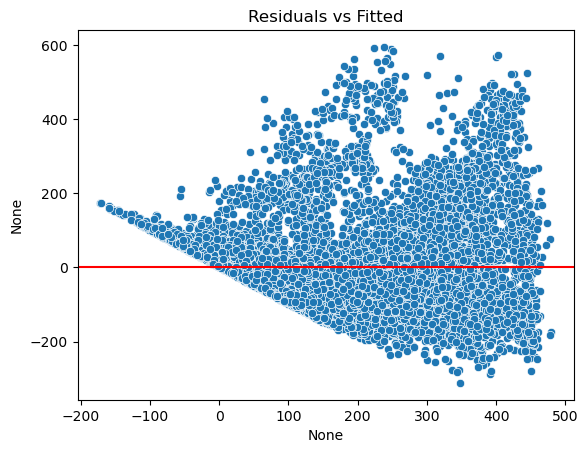

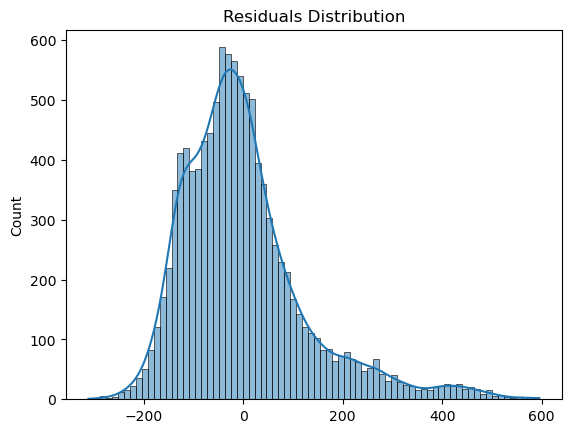

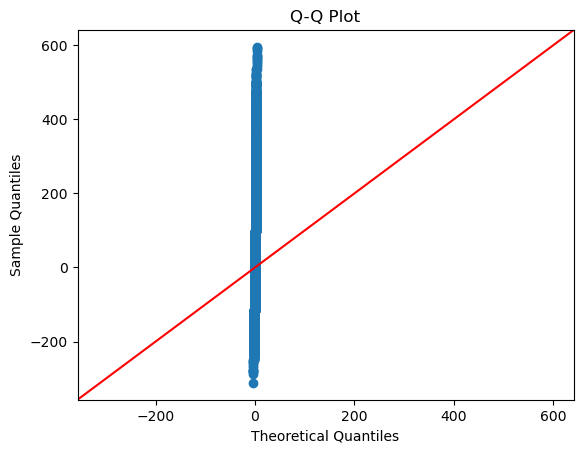

     Variable        VIF
0       const  24.079618
1        temp   5.659904
2    humidity   1.918003
3   windspeed   1.188045
4        year   1.036197
5   weather_2   1.178076
6   weather_3   1.265621
7     month_2   1.883422
8     month_3   2.117458
9     month_4   2.430384
10    month_5   3.122963
11    month_6   4.034827
12    month_7   5.090140
13    month_8   4.771718
14    month_9   3.805605
15   month_10   2.839263
16   month_11   2.086660
17   month_12   2.045891
18    dow_Sat   1.034377
19    dow_Sun   1.036269
20   hour_sin   1.448650
21   hour_cos   1.256895


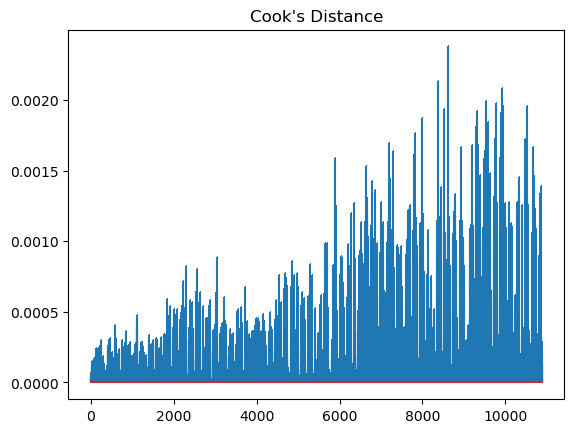

In [113]:
# Diagnostics
residuals = model_scaled.resid
fitted = model_scaled.fittedvalues

# Residuals vs Fitted (linearity + homoscedasticity)
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red')
plt.title('Residuals vs Fitted')
plt.show()
plt.close()

# Histogram of Residuals (normality)
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()
plt.close()

# Q-Q Plot (normality)
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot")
plt.show()
plt.close()

# VIF (Multicollinearity)
X_scaled = sm.add_constant(X_scaled)
vif = pd.DataFrame()
vif['Variable'] = X_scaled.columns
vif['VIF'] = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
print(vif)

# Influence (Cook's distance)
influence = model_reduced.get_influence()
(c, p) = influence.cooks_distance
plt.stem(np.arange(len(c)), c, markerfmt=",")
plt.title("Cook's Distance")
plt.show()
plt.close()

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>In order to confirm heteroscedasticity, Breusch-Pagan test and White test were conducted.</li>
    <li>Both tests proved the evidence of heteroscedasticity.</li>
    <li>Breusch-Pagan Test:</li>
    <ul>
        <li>Null hypothesis: Error variance is constant (homoscedasticity).</li>
        <li>Alternative hypothesis: Error variance is not constant (heteroscedasticity)</li>
        <li>p < 0.05, null hypothesis is rejected, suggesting there is evidence of heteroscedasticity.</li>
    </ul>
    <li>White Test:</li>
    <ul>
        <li>Null hypothesis: Error variance is constant (homoscedasticity) </li>
        <li>Alternative hypothesis: Error variance is not constant (heteroscedasticity) or model misspecification.</li>
        <li>p < 0.05, null hypothesis is rejected, suggesting there is eveidence of heteroscedasticity.</li>
</ul>
</div>

In [114]:
# Residuals and design matrix (predictors)
residuals = model_scaled.resid
exog = model_scaled.model.exog

# Run Breusch-Pagan test
bp_test = het_breuschpagan(residuals, exog)

# Results
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, bp_test)))

{'Lagrange multiplier statistic': np.float64(1354.0774890961527), 'p-value': np.float64(6.433227050315941e-274), 'f-value': np.float64(73.49088499454432), 'f p-value': np.float64(3.000729315719735e-293)}


In [115]:
# Residuals and design predictors
residuals = model_scaled.resid
exog = model_scaled.model.exog

# Run White's test
white_test = het_white(residuals, exog)

# Results
labels = ['LM Statistic', 'LM p-value', 'F-statistic', 'F p-value']
print(dict(zip(labels, white_test)))

{'LM Statistic': np.float64(2273.988389700773), 'LM p-value': np.float64(0.0), 'F-statistic': np.float64(15.882959800195929), 'F p-value': np.float64(0.0)}


<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>Since heteroscedasticity has been confirmed, I need to refit regression using heteroscedasticity-consistent(HC) standard errors, particularly HC3 to ensure valid inference.</li>
    <li>This adjustment corrects the bias in standard errors without altering coefficient estimates.</li>
</ul>
</div>

In [116]:
# Refit OLS with robust standard errors
robust_model = model_scaled.get_robustcov_results(cov_type='HC3')

# Summary of results
print(robust_model.summary())

                            OLS Regression Results                            
Dep. Variable:            total_users   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     547.2
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:59:33   Log-Likelihood:                -68112.
No. Observations:               10886   AIC:                         1.363e+05
Df Residuals:                   10864   BIC:                         1.364e+05
Df Model:                          21                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        125.6402      5.203     24.146      0.0

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>Looking at refit OLS Regression Results below, R-squared and Adj. R-squared increased from ~0.514 to ~0.622.</li>
    <li>Prob (F-stat) remains statistically significant.</li>
    <li>AIC and BIC values decreased substantially, indicating improved model fit.</li>
    <li>'humidity' and 'dow_Sun' turned insignificant (p > 0.05) in this logged model.</li>
    <li>Next course of action is to try and drop them one by one, while observing changes in R-squared and Adj. R-squared.</li>
</ul>
</div>

In [117]:
# Log transform 'total_users'
df_encoded['log_total_users'] = np.log(df_encoded['total_users'])

# Refit regression
X_scaled = sm.add_constant(X_scaled)
model_log = sm.OLS(df_encoded['log_total_users'], X_scaled).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:        log_total_users   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     851.5
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:59:33   Log-Likelihood:                -14484.
No. Observations:               10886   AIC:                         2.901e+04
Df Residuals:                   10864   BIC:                         2.917e+04
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8851      0.043     90.153      0.0

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>By dropping 'humidity', R-squared maintained at 0.622 and Prob (F-stats) maintained significant.
    <li>Next course of action is to observe changes in R-squared if 'dow_Sun' is dropped.</li>
</ul>
</div>

In [118]:
# Re-run regression excluding dow_Tue, dow_Wed, dow_Thu, dow_Fri, humidity
X_scaled = df_encoded[
    ['temp', 'windspeed', 'year', 'weather_2', 'weather_3']
    + [col for col in df_encoded.filter(like='month_').columns
       if col not in ['month_sin', 'month_cos']]
    + [col for col in df_encoded.filter(like='dow_').columns
       if col not in ['dow_Tue', 'dow_Wed', 'dow_Thu', 'dow_Fri']]
    + list(df_encoded.filter(like='hour_'))
]             
y = df_encoded['log_total_users']

X_scaled = sm.add_constant(X_scaled)
model_log = sm.OLS(y, X_scaled).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:        log_total_users   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     893.7
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:59:33   Log-Likelihood:                -14486.
No. Observations:               10886   AIC:                         2.901e+04
Df Residuals:                   10865   BIC:                         2.917e+04
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8722      0.042     91.144      0.0

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>By dropping 'dow_Sun', R-squared maintained at 0.622, prob (f-stat) too remain significant.</li>
    <li>Other variables appear to be significant (p < 0.05).</li>
</ul>
</div>

In [119]:
# Re-run regression excluding dow_Tue, dow_Wed, dow_Thu, dow_Fri, humidity, dow_Sun
X_scaled = df_encoded[
    ['temp','windspeed', 'year', 'weather_2', 'weather_3']
    + [col for col in df_encoded.filter(like='month_').columns
       if col not in ['month_sin', 'month_cos']]
    + [col for col in df_encoded.filter(like='dow_').columns
       if col not in ['dow_Tue', 'dow_Wed', 'dow_Thu', 'dow_Fri', 'dow_Sun']]
    + list(df_encoded.filter(like='hour_'))
]             
y = df_encoded['log_total_users']

X_scaled = sm.add_constant(X_scaled)
model_log = sm.OLS(y, X_scaled).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:        log_total_users   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     940.8
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:59:33   Log-Likelihood:                -14486.
No. Observations:               10886   AIC:                         2.901e+04
Df Residuals:                   10866   BIC:                         2.916e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8735      0.042     91.539      0.0

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>Hour of day has a strong cyclical effect. Rentals peak in the afternoon around 15:00 and are lowest in the early morning around 03:00.</li>
    <li>The effect was modeled on a log scale, so the plotted values represent multiplicative contributions rather than raw counts.</li>
</ul>
</div>

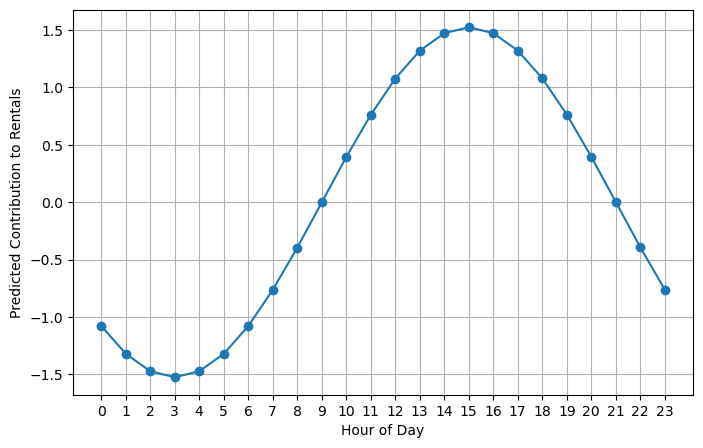

In [120]:
# Regression coefficient from logged model
beta_sin = -1.0794
beta_cos = -1.0776

# Hour of day
hours = np.arange(0,24)

# Compute hourly effect
hour_effect = beta_sin * np.sin(2 * np.pi * hours /24) + beta_cos * np.cos(2 * np.pi * hours / 24)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(hours, hour_effect, marker='o')
plt.xlabel("Hour of Day")
plt.ylabel("Predicted Contribution to Rentals")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()
plt.close()

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>Residuals vs fitted plot for the baseline model showed a fan-out pattern, indicating heteroscedasticity. After log transformation, the plot suggested improved variance stability.</li>
    <li>Residual distribution in the baseline model was right-skewed, violating normality assumption. After log transformation, residuals become approximately symmetrical and centered around zero, indicating improved normality. This correction strengthens inference reliability, though residual variance pattern suggest heteroscedasticity still present.</li>
    <li>The Q-Q plot for the baseline model showed strong departure from normality. After log transformation, residuals aligned closely with the theoretical normal line.This indicates that the log model meets the normality assumptions more convincingly, strengthening inference reliability.</li>
    <li>VIF remained unchanged before and after log transformation, indicating stable predictor relationship and no evidence of multicollinearity.</li>
    <li>Cook's Distance values remained uniformly low before and after log transformation. While few observations showed relatively higher influence, none exceeded conventional thresholds. This indicates that model results are not driven by individual outliers, and influential points are not a concern.</li>
</ul>  
</div>

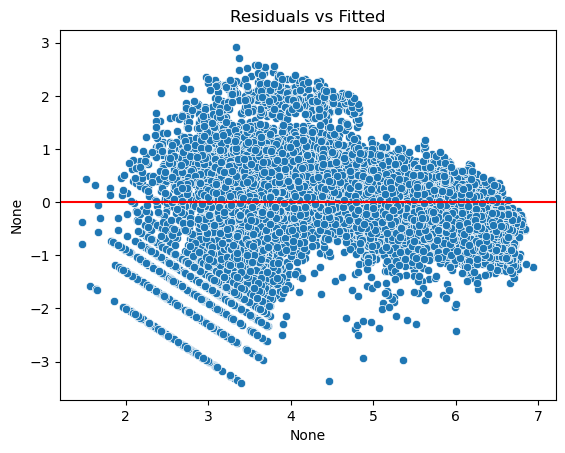

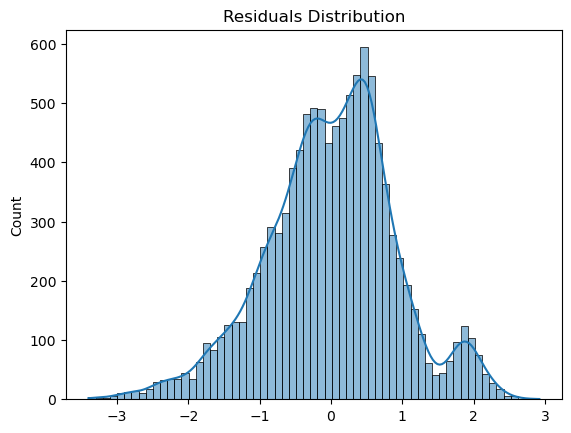

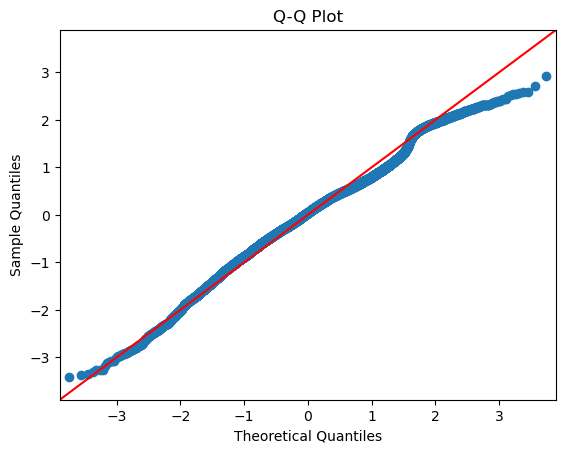

     Variable        VIF
0       const  23.213575
1        temp   5.641875
2   windspeed   1.123501
3        year   1.025787
4   weather_2   1.054302
5   weather_3   1.046463
6     month_2   1.883192
7     month_3   2.116106
8     month_4   2.429182
9     month_5   3.068960
10    month_6   4.019490
11    month_7   5.072390
12    month_8   4.733314
13    month_9   3.712179
14   month_10   2.780378
15   month_11   2.075387
16   month_12   2.005058
17    dow_Sat   1.003641
18   hour_sin   1.266577
19   hour_cos   1.142921


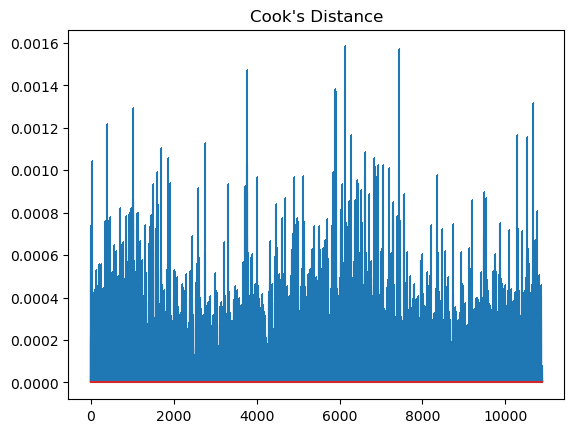

In [121]:
# Diagnostics
residuals = model_log.resid
fitted = model_log.fittedvalues

# Residuals vs Fitted (linearity + homoscedasticity)
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red')
plt.title('Residuals vs Fitted')
plt.show()
plt.close()

# Histogram of Residuals (normality)
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution")
plt.show()
plt.close()

# Q-Q Plot (normality)
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot")
plt.show()
plt.close()

# VIF (Multicollinearity)
from statsmodels.stats.outliers_influence import variance_inflation_factor
# X_reduced = df[['temp', 'humidity', 'windspeed']]
X_scaled = sm.add_constant(X_scaled)
vif = pd.DataFrame()
vif['Variable'] = X_scaled.columns
vif['VIF'] = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
print(vif)

# Influence (Cook's distance)
influence = model_log.get_influence()
(c, p) = influence.cooks_distance
plt.stem(np.arange(len(c)), c, markerfmt=",")
plt.title("Cook's Distance")
plt.show()
plt.close()

<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>The results shown in Breusch-Pagan and White tests proved that heteroscedasticity (p < 0.05) persists in the model, even after log transformation.</li>
</ul>
</div>

In [122]:
# Residuals and design matrix (predictors)
residuals = model_log.resid
exog = model_log.model.exog

# Run Breusch-Pagan test
bp_test = het_breuschpagan(residuals, exog)
# Results
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, bp_test)))

{'Lagrange multiplier statistic': np.float64(2341.3287753417403), 'p-value': np.float64(0.0), 'f-value': np.float64(156.70510527904662), 'f p-value': np.float64(0.0)}


In [123]:
# Residuals and design predictors
residuals = model_log.resid
exog = model_log.model.exog

# Run White's test
white_test = het_white(residuals, exog)

# Results
labels = ['LM Statistic', 'LM p-value', 'F-statistic', 'F p-value']
print(dict(zip(labels, white_test)))

{'LM Statistic': np.float64(3125.355225503539), 'LM p-value': np.float64(0.0), 'F-statistic': np.float64(31.594295197052663), 'F p-value': np.float64(0.0)}


<div style="background-color: #e6f7ff; padding: 10px;">
<ul>
    <li>The OLS regression has been refitted with robust standard errors (HC3) to make inference more reliable when heteroscedasticity is present. </li>
</ul>
</div>

In [124]:
# Refit OLS with robust standard errors using logged model
robust_model_logged = model_log.get_robustcov_results(cov_type='HC3')

# Summary of results
print(robust_model_logged.summary())

                            OLS Regression Results                            
Dep. Variable:        log_total_users   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.621
Method:                 Least Squares   F-statistic:                     894.4
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:59:41   Log-Likelihood:                -14486.
No. Observations:               10886   AIC:                         2.901e+04
Df Residuals:                   10866   BIC:                         2.916e+04
Df Model:                          19                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8735      0.043     90.762      0.0

## 6. COMMUNICATION AND REPORTING

<div style="background-color: #e6f7ff; padding: 10px;">
<b>RESULTS</b><br>
<ul>
    <li>Key predictors of bike rentals (log model with HC3 robust SEs):</li>
    <ul>
        <li>Bike rentals follow a clear daily cycle. The highest rentals is during afternoon around 3pm, while the lowest is around 3am.</li>
        <li>June-August show the strongest positive effect on bike rentals, followed by September-November, then December-February, with March-May having the weakest relative effect.</li>
        <li>Light precipitation (weather_3) has the strongest negative effect on bike rentals compared to baseline clear weather, followed by misty (weather_2), then lastly windspeed.</li>
        <li>Temperature has a positive effect in bike rentals.</li>
        <li>Year 2012 shows an increase in bike rentals compared to baseline year 2011.</li>
        <li>Saturday has higher rentals compared to baseline Monday.</li>
        <!-- <li> --- Findings before including datetime variable into the analysis --- </li> -->
        <!-- <li>Season 4 (winter): Strongest positive effect compared to baseline spring.</li>
        <li>Weather 2 (misty): Second strongest positive effect.</li>
        <li>Season 3 (fall): Strongest negative effect compared to baseline spring.</li>
        <li>Humidity: Second strongest negative effect.</li>
        <li>Temperature: Strong positive effect.</li>
        <li>Windspeed: Positive but weaker effect.</li> -->
    </ul>
</ul>
<b>DIAGNOSTICS</b><br>
<ul>
    <li>Baseline model (before log):</li>
    <ul>
        <li>Residuals vs fitted: Fan-out pattern, signifying heteroscedasticity.</li>
        <li>Residual distribution: Right-skewed, non-normal distribution.</li>
        <li>Q-Q Plot: Strong deviations from normal line.</li>
        <li>VIF: No multicollinearity.</li>
        <li>Cook's Distance: No influential outliers.</li>
        <li>Breush-Pagan and White test confirmed evidence of heteroscedasticity.</li>
    </ul>
    <li>Logged model (after log):</li>
    <ul>
        <li>Residuals vs fitter: Fan-in pattern, heteroscedasticity persisted.</li>
        <li>Residual distribution: Symmetric, near normal.</li>
        <li>Q-Q Plot: Aligned with normal line.</li>
        <li>VIF: Remain unchanged, no multicollinearity.</li>
        <li>Cook's Distance: No influential outliers.</li>
        <li>Breusch-Pagan and White test confirmed heteroscedasticity persists.</li>
    </ul>
</ul>
<b>CORRECTIVE ACTION</b><br>
<ul>
    <li>Issue: Heteroscedasticity persisted even after log transformation.</li>
    <li>Solution: Applied HC3 robust standard errors to logged model.</li>
    <li>Impact: Coefficients unchanged, but inference (p-values, confidence intervals) corrected for non-constant variance.</li>
    <li>Conclusion: The logged model with robust SEs provides valid inference and reliable insights into predictos of bike rentals.</li>
</ul>
<b>FINAL STATEMENT</b><br>
<ul>
    <li>Log transformation improved residual normality but did not eliminate heteroscedasticity. Robust standard errors (HC3) were applied to ensure valid inference.</li>
    <li>The final model confirms that bike rentals were positively affected by hour of the day, month of the year compared to baseline January, and on Saturday when compared to baseline Monday. Misty weather negatively affects bike rentals. Temperature has weak positive effect, while light precipitation weather and windspeed have weak negative effects on bike rentals. </li>
    <!-- <li>The final model confirms that winter and misty weather increase bike rentals, while fall and humidity reduce them, with temperature and windspeed also contributing positively./li> -->
</ul>
</div>

# To-Do List (ALMOST DONE!):
1. Edit Table of Contents